In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

from src import config

In [2]:
DATE_COLS = ["date"]
NUMERIC_COLS = ["year", "depth (m)", "total"]


def load_reef_check_data(path: str) -> pd.DataFrame:
    """Load and process Reef Check substrate data"""
    df = pd.read_csv(
        path,
        parse_dates=DATE_COLS,
        date_format=lambda x: pd.to_datetime(x, format="%Y-%m-%d", errors="coerce"),
        low_memory=False,
    )

    # coerce columns to numeric. 'coerce' sets bad values to nan
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["depth (m)"] = pd.to_numeric(df["depth (m)"], errors="coerce").astype("Float64")
    df["total"] = pd.to_numeric(df["total"], errors="coerce").astype("Int64")
    df["date"] = pd.to_datetime(df["date"], format="%d-%B-%y", errors="coerce")

    # split 'coordinates_in_decimal_degree_format' into 'latitude' and 'longitude'
    latlon_cols = df["coordinates_in_decimal_degree_format"].str.split(",", expand=True)
    latlon_cols = latlon_cols.apply(pd.to_numeric, errors="coerce")
    latlon_cols.columns = ["latitude", "longitude"]
    df[["latitude", "longitude"]] = latlon_cols

    return df


data_fp = config.reef_check_dir / "021126" / "Substrate.csv"
df = load_reef_check_data(data_fp)

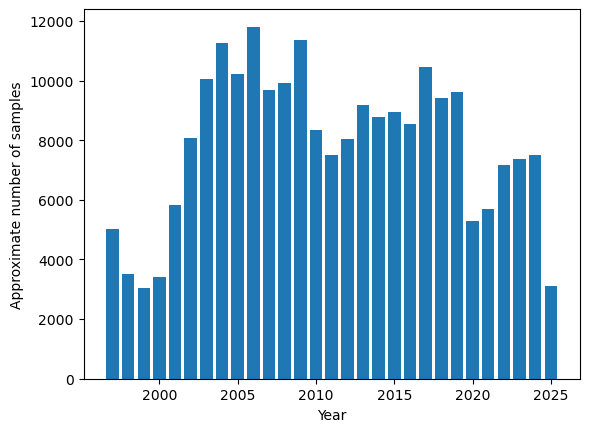

In [3]:
years = df.year.value_counts().sort_index()
plt.bar(years.index, years.values / 4)
plt.xlabel("Year")
plt.ylabel("Approximate number of samples")
plt.show()

In [4]:
def summarise_errors(df: pd.DataFrame, errors_csv_fp: str | Path) -> pd.DataFrame:
    """Filter rows with marked errors e.g. incomplete substrate"""

    # proportion of data with errors of some kind
    print(
        f"{100 * len(df[df['errors'] == True]) / len(df):.02f}% of rows contain errors"
    )
    # select errors corresponding to substrate
    error_info = df[
        df["what_errors"].notna()
        & (
            df["what_errors"].str.contains("substrate")
            | df["what_errors"].str.contains(r"S[1-4]", regex=True)
        )
    ].what_errors.value_counts()

    if not Path(errors_csv_fp).exists():
        # save error info to csv
        error_info.to_csv(errors_csv_fp)
        print(f"Now go and manually filter errors in {errors_csv_fp}")
    else:
        print(f"Error summary already exists at {errors_csv_fp}")


def remove_errors(
    df: pd.DataFrame, completed_errors_csv_fp: str | Path
) -> pd.DataFrame:
    """Remove rows with marked errors using csv with "S*" 0/1 columns

    Args:
        df (pd.DataFrame): Reef Check substrate data
        completed_errors_csv_fp (str | Path): Path to csv with "S*" 0/1 columns

    Returns:
        pd.DataFrame
    """
    # remove any rows where 'total' is nan
    df = df[df["total"].notna()]
    error_info_complete = pd.read_csv(completed_errors_csv_fp)
    seg_cols = [c for c in ["S1", "S2", "S3", "S4"] if c in error_info_complete.columns]

    drop_rules = (
        error_info_complete.assign(
            what_errors=lambda d: d["what_errors"].fillna("").str.strip().str.lower(),
            **{
                c: pd.to_numeric(error_info_complete[c], errors="coerce")
                .fillna(0)
                .astype(int)
                for c in seg_cols
            },  # ensure full and integers
        )
        .melt(
            id_vars="what_errors",
            value_vars=seg_cols,
            var_name="segment_code",
            value_name="keep",
        )  # melt into long format
        .query("keep == 0")[["what_errors", "segment_code"]]
        .drop_duplicates()
    )

    df.loc[:, "what_errors"] = df["what_errors"].fillna("").str.strip().str.lower()
    df.loc[:, "segment_code"] = (
        df["segment_code"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(r"^SEGMENT\s*", "", regex=True)
        .str.replace(r"^S\s*", "S", regex=True)
        .str.replace(r"^(\d)$", r"S\1", regex=True)
    )  # ensure consistency in segment_code field

    n0 = len(df)
    df = df.merge(
        drop_rules.assign(_drop=True), on=["what_errors", "segment_code"], how="left"
    )
    df = df[df["_drop"].isna()].drop(columns="_drop")
    print(
        f"Dropped {n0 - len(df):,}; kept {len(df):,}/{n0:,} ({100 * len(df) / n0:.2f}%)."
    )
    return df


summarise_errors(df, config.sully_og_dir / "reefcheck_error_info.csv")
processed_df = remove_errors(
    df, config.sully_og_dir / "reefcheck_error_info_completed.csv"
)

21.09% of rows contain errors
Error summary already exists at /Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/sully_og/reefcheck_error_info.csv
Dropped 11,921; kept 898,560/910,481 (98.69%).


In [5]:
def filter_substrate_total_errors(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove all rows belonging to any (survey_id, segment_code) group
    where the sum of 'total' is not 40. Works safely for any length of df.
    """
    # Ensure 'total' is numeric for correct groupby aggregation
    df = df.copy()
    gb = df.groupby(["survey_id", "segment_code"])["total"].sum()
    # Identify all (survey_id, segment_code) tuples where sum != 40
    bad_keys = set(gb.index[gb != 40])
    # Mask: True for good rows only
    mask = ~df.set_index(["survey_id", "segment_code"]).index.isin(bad_keys)
    print(
        f"Dropped {len(df) - len(df[mask]):,} rows ({100 * len(df[~mask]) / len(df):.02f}%)."
    )
    return df[mask].reset_index(drop=True)


processed_df = filter_substrate_total_errors(processed_df)

Dropped 4,602 rows (0.51%).


In [6]:
def check_segment_accuracy(df: pd.DataFrame) -> list[str]:
    """Return a list of survey_ids where the sum of total is not 160"""
    # Find survey_ids where the sum of total is not 160
    bad_surveys = (
        df.groupby(["survey_id", "segment_code"])["total"]
        .sum()
        .loc[lambda s: s != 160]
        .index.tolist()
    )
    print(f"Surveys with total != 160: {bad_surveys}")
    problem_surveys = df[df["survey_id"].isin(bad_surveys)]
    problem_surveys.groupby("survey_id")["total"].sum()


def calculate_cover(df: pd.DataFrame, substrate_code: str = "HC") -> pd.Series:
    """Calculate the proportional cover [0, 1] of a given substrate code"""
    # calculate coral cover for each site (sum of HR field averaged over 40 quadrats)
    return (
        df.query(f"substrate_code == '{substrate_code}'")
        .groupby(["survey_id", "segment_code"])["total"]
        .sum()
        .div(40)
    )


bad_surveys = check_segment_accuracy(processed_df)
if bad_surveys:
    raise ValueError(f"Surveys with total != 160: {bad_surveys}")
else:
    coral_covers = calculate_cover(processed_df)
    survey_cover = coral_covers.groupby("survey_id").mean().rename("coral_cover")
    # create df for coral cover keeping only relevant columns (retaining first value of each of the other columns)
    cols_to_discard = [
        "substrate_code",
        "segment_code",
        "total",
        "substrate_recorded_by",
        "errors",
        "what_errors",
    ]
    # discard the columns
    coral_covers_df = processed_df.drop(columns=cols_to_discard)
    # # keep only the first value of each of the other columns
    coral_covers_df = coral_covers_df.drop_duplicates(subset=["survey_id"])
    coral_covers_df["coral_cover"] = coral_covers_df["survey_id"].map(survey_cover)

coral_covers_df.loc[:, "days_since_19811231"] = coral_covers_df.apply(
    lambda row: (row["date"] - pd.Timestamp("1981-12-31")).days, axis=1
)
coral_covers_df["Depth"] = pd.to_numeric(
    coral_covers_df["depth (m)"], errors="coerce"
).astype("float")

# export df to processed file
output_dir = config.reef_check_dir / "processed"
output_dir.mkdir(parents=True, exist_ok=True)
coral_covers_df.to_csv(
    output_dir / f"coral_covers_processed_{data_fp.parent.stem}.csv", index=False
)

Surveys with total != 160: [('000887f9-b8c4-4c43-bc63-700c0e8b385b', 'S1'), ('000887f9-b8c4-4c43-bc63-700c0e8b385b', 'S2'), ('000887f9-b8c4-4c43-bc63-700c0e8b385b', 'S3'), ('000887f9-b8c4-4c43-bc63-700c0e8b385b', 'S4'), ('00103835-7d8a-4099-a58b-bac77e8e81bc', 'S1'), ('00103835-7d8a-4099-a58b-bac77e8e81bc', 'S2'), ('00103835-7d8a-4099-a58b-bac77e8e81bc', 'S3'), ('00103835-7d8a-4099-a58b-bac77e8e81bc', 'S4'), ('0016ef4b-d18c-4ace-a821-ec622688a708', 'S1'), ('0016ef4b-d18c-4ace-a821-ec622688a708', 'S2'), ('0016ef4b-d18c-4ace-a821-ec622688a708', 'S3'), ('0016ef4b-d18c-4ace-a821-ec622688a708', 'S4'), ('001a09e0-e52f-4adf-bb2d-e66e2bacb3b5', 'S1'), ('001a09e0-e52f-4adf-bb2d-e66e2bacb3b5', 'S2'), ('001a09e0-e52f-4adf-bb2d-e66e2bacb3b5', 'S3'), ('001a09e0-e52f-4adf-bb2d-e66e2bacb3b5', 'S4'), ('001adbf1-e2eb-4ef7-b600-bd8a923e0020', 'S1'), ('001adbf1-e2eb-4ef7-b600-bd8a923e0020', 'S2'), ('001adbf1-e2eb-4ef7-b600-bd8a923e0020', 'S3'), ('001adbf1-e2eb-4ef7-b600-bd8a923e0020', 'S4'), ('002b8a36-8

In [7]:
data_fp.parent.stem


'021126'

In [8]:
coral_covers_df.shape

(17319, 25)

Bridge rows (pre-resolution): 6,899
Ambiguous survey matches: 75
Tie-breaker usage:
tie_breaker
unique       6710
fallback       67
archived        5
reef_name       3


,survey_id,site_id,reef_name,Reef_ID,coral_cover
53,0224a510-f772-40d5-a9c2-7d26bebcf8e0,b3609b45-e0aa-4546-82b6-79b763e0d402,Ninh Thuan Site 10,109.7.24.1E.11.33.55.19N,0.10625
228,08409cfa-aa02-4636-b5d8-b87ab64706b8,0d8be3f7-54f3-41d8-8927-6fcafb46aacb,West Fore Reef,77.24.713W.18.28.370N,0.0625
261,09b3ddd4-3a5b-4e02-b918-2cc19dbc17d8,9f49c037-6b18-49bf-b52c-cf0fe015f387,AMPO- AM04,720414E.1108070N,0.775
493,11ce2f29-c368-4a8e-bfe8-61be22d04060,5dc5f82e-81de-4fa0-9061-1276508a5e74,Labuana 3,119.79910E.0.15014N,0.21875
681,184347c6-00b8-4057-ae8a-13bb88e96fac,f4eda222-8ecc-4403-8843-5102bafe9a1c,Bohayan Island,4N118E24,0.31875
746,1af6d8ea-057f-4737-a195-b7e0f312bed2,d3137ec5-2acc-4bc0-a4b8-0e636681adfd,Cust Reef,118.37.889E.4.14.956N,0.23125
945,22ae585d-00ef-4c35-97fc-53515a8104d7,087923f9-c05f-4d92-8d1d-7c969143b7e8,Takun,4N118E32,0.625
974,2435bfa1-5987-44f4-a4ec-243fcbfbe8c2,fc34a8ce-b3be-45a4-92d5-92adf2e5bb40,Paradise 2,118.37.49.78E.4.14.59.37N,0.26875
1042,26d08e49-633d-4bcc-9551-4aa7247bb174,ea89c197-d195-4366-a1b2-cf49f15d7b82,Laila Island,4N118E26,0.79375
1081,27b80162-21d4-4d8b-b4d4-2378adafcb6b,cbe9a719-82ae-4885-8def-50d9b7a4c3cf,Moore Reef Site 2,146.12.16.8E.16.52.21S,0.325


Post-resolution mismatches (>0.00625): 0


(0.0, 1.0)

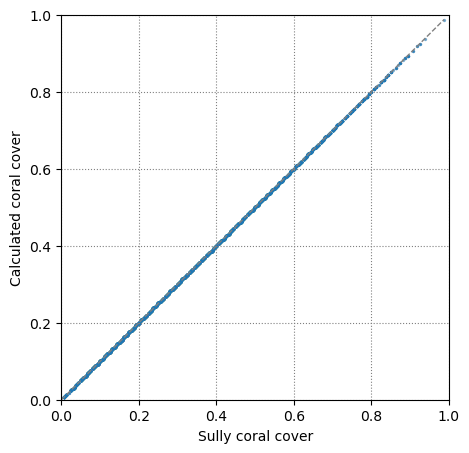

In [9]:
ARCHIVED_REEF_ID_COL = "static_descriptors_reef_id (archived field)"  # unique for each
SULLY_REEF_ID_COL = "Reef_ID_sully"  # however Sully devised theirs

df_for_maps = pd.read_csv(config.sully_og_dir / "data_for_maps.csv")
# Same for df_for_maps — round before converting to float
df_for_maps["Depth"] = pd.to_numeric(df_for_maps["Depth"], errors="coerce").astype(
    "float"
)


def _normalize_name(value: object) -> str:
    if pd.isna(value):
        return ""
    return (
        str(value).lower().replace("`", "").replace("'", "").replace(",", " ").strip()
    )


def _name_match_score(reef_name: str, row: pd.Series) -> int:
    """Score how well a Sully row's place names match substrate reef_name."""
    rn = _normalize_name(reef_name)
    if not rn:
        return 0

    score = 0
    for col in ("City_Town", "City_Town_2", "City_Town_3"):
        val = _normalize_name(row.get(col))
        if not val:
            continue
        if val in rn or rn in val:
            score += 3
        for token in val.split():
            if len(token) > 3 and token in rn:
                score += 1

    # Helpful for house-reef pairs that share City_Town_2 (e.g. Lawaki North/South)
    for hint in ("north", "south", "east", "west"):
        if hint in rn and hint in _normalize_name(
            " ".join(str(row.get(c, "") or "") for c in ("City_Town_2", "City_Town_3"))
        ):
            score += 2

    return score


def resolve_survey_reef_id(group: pd.DataFrame) -> pd.Series:
    """Pick one Sully Reef_ID when (days, depth, cover) matches multiple sites."""
    candidates = group[SULLY_REEF_ID_COL].dropna().unique()
    if len(candidates) == 1:
        row = group.iloc[0]
        return pd.Series(
            {
                SULLY_REEF_ID_COL: candidates[0],
                "sully_site": row["sully_site"],
                "tie_breaker": "unique",
            }
        )

    # 1) archived Reef_ID from Substrate.csv
    archived = group["archived_reef_id"].iloc[0]
    if pd.notna(archived):
        archived_hits = group[group[SULLY_REEF_ID_COL] == archived]
        if len(archived_hits) == 1:
            row = archived_hits.iloc[0]
            return pd.Series(
                {
                    SULLY_REEF_ID_COL: row[SULLY_REEF_ID_COL],
                    "sully_site": row["sully_site"],
                    "tie_breaker": "archived",
                }
            )

    # 2) reef_name vs City_Town fields
    reef_name = group["reef_name"].iloc[0]
    scored = group.copy()
    scored["name_score"] = scored.apply(
        lambda r: _name_match_score(reef_name, r), axis=1
    )
    best_score = scored["name_score"].max()
    if best_score > 0:
        top = scored[scored["name_score"] == best_score]
        if len(top) == 1:
            row = top.iloc[0]
            return pd.Series(
                {
                    SULLY_REEF_ID_COL: row[SULLY_REEF_ID_COL],
                    "sully_site": row["sully_site"],
                    "tie_breaker": "reef_name",
                }
            )

    # 3) fallback — stable choice, flagged for manual review
    row = group.sort_values(SULLY_REEF_ID_COL).iloc[0]
    return pd.Series(
        {
            SULLY_REEF_ID_COL: row[SULLY_REEF_ID_COL],
            "sully_site": row["sully_site"],
            "tie_breaker": "fallback",
        }
    )


# --- 1. Substrate: one row per survey ---
survey_cols = [
    "survey_id",
    "site_id",
    "reef_name",
    "days_since_19811231",
    "Depth",
    "coral_cover",
]
if ARCHIVED_REEF_ID_COL in coral_covers_df.columns:
    survey_cols.append(ARCHIVED_REEF_ID_COL)

survey_df = coral_covers_df[survey_cols].drop_duplicates("survey_id").copy()
survey_df = survey_df.rename(
    columns={ARCHIVED_REEF_ID_COL: "archived_reef_id"}
    if ARCHIVED_REEF_ID_COL in survey_cols
    else {}
)
if "archived_reef_id" not in survey_df.columns:
    survey_df["archived_reef_id"] = pd.NA

# --- 2. Sully: one row per survey record ---
sully_df = df_for_maps[
    [
        "Reef_ID",
        "site",
        "days_since_19811231",
        "Depth",
        "Average_coral_cover",
        "City_Town",
        "City_Town_2",
        "City_Town_3",
    ]
].copy()
sully_df["Depth"] = pd.to_numeric(sully_df["Depth"], errors="coerce")
sully_df["days_since_19811231"] = pd.to_numeric(
    sully_df["days_since_19811231"], errors="coerce"
)

# --- 3. Primary match on (date, depth, cover) ---
bridge = survey_df.merge(
    sully_df.rename(columns={"Reef_ID": SULLY_REEF_ID_COL, "site": "sully_site"}),
    left_on=["days_since_19811231", "Depth", "coral_cover"],
    right_on=["days_since_19811231", "Depth", "Average_coral_cover"],
    how="inner",
)

bridge["n_reef_matches"] = bridge.groupby("survey_id")[SULLY_REEF_ID_COL].transform(
    "nunique"
)
ambiguous = bridge[bridge["n_reef_matches"] > 1].copy()

# --- 4. Tie-break ambiguous survey matches ---
survey_matches = (
    bridge.groupby("survey_id", group_keys=False)
    .apply(resolve_survey_reef_id, include_groups=False)
    .reset_index()
)

# --- 5. One row per matched survey (Sully metadata attached) ---
sully_lookup = sully_df.rename(columns={"Reef_ID": SULLY_REEF_ID_COL}).drop_duplicates(
    subset=[
        SULLY_REEF_ID_COL,
        "days_since_19811231",
        "Depth",
        "Average_coral_cover",
    ]
)[
    [
        SULLY_REEF_ID_COL,
        "days_since_19811231",
        "Depth",
        "Average_coral_cover",
        "City_Town",
        "City_Town_2",
        "City_Town_3",
    ]
]

resolved = survey_df.merge(survey_matches, on="survey_id", how="inner")
resolved = resolved.merge(
    sully_lookup,
    left_on=[
        SULLY_REEF_ID_COL,
        "days_since_19811231",
        "Depth",
        "coral_cover",
    ],
    right_on=[
        SULLY_REEF_ID_COL,
        "days_since_19811231",
        "Depth",
        "Average_coral_cover",
    ],
    how="left",
    validate="m:1",
)

# --- 6. site_id -> canonical Sully Reef_ID (for reuse across surveys) ---
site_bridge = (
    resolved.groupby("site_id")
    .agg(
        Reef_ID=(SULLY_REEF_ID_COL, lambda s: s.mode().iloc[0]),
        sully_site=("sully_site", lambda s: s.mode().iloc[0]),
        n_surveys=("survey_id", "nunique"),
    )
    .reset_index()
)

merged_df = resolved.rename(columns={SULLY_REEF_ID_COL: "Reef_ID"})

# --- diagnostics ---
print(f"Bridge rows (pre-resolution): {len(bridge):,}")
print(f"Ambiguous survey matches: {ambiguous['survey_id'].nunique():,}")
print("Tie-breaker usage:")
print(merged_df["tie_breaker"].value_counts(dropna=False).to_string())
if merged_df["tie_breaker"].eq("fallback").any():
    display(
        merged_df.loc[
            merged_df["tie_breaker"] == "fallback",
            ["survey_id", "site_id", "reef_name", "Reef_ID", "coral_cover"],
        ].head(20)
    )

merged_df["abs_diff"] = (
    merged_df["coral_cover"] - merged_df["Average_coral_cover"]
).abs()
print(
    f"Post-resolution mismatches (>{1 / 160:.5f}): "
    f"{(merged_df['abs_diff'] > 1 / 160 + 1e-9).sum():,}"
)


max_cover = max(
    (np.nanmax(merged_df["Average_coral_cover"])), np.nanmax((merged_df["coral_cover"]))
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(merged_df["Average_coral_cover"], merged_df["coral_cover"], s=2, alpha=0.5)
ax.plot([0, max_cover], [0, max_cover], color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Sully coral cover")
ax.set_ylabel("Calculated coral cover")
ax.grid("--", color="grey", ls=":")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Sully-esque processing

In [10]:
# rename columns for convenience
coral_covers_df.drop(columns="Depth", inplace=True)
coral_covers_df.rename(columns={"depth (m)": "depth"}, inplace=True)

# remove rows with nan values in vital rows
cols_to_remove_nans = ["latitude", "longitude", "depth", "coral_cover", "date"]

print(f"{len(coral_covers_df)} rows before removing nans")
for col in cols_to_remove_nans:
    num_nans = len(coral_covers_df[coral_covers_df[col].isna()])
    row_str = "row" if num_nans == 1 else "rows"
    print(f"Removed {num_nans} {row_str} with nan values for {col}")
    coral_covers_df = coral_covers_df[coral_covers_df[col].notna()]

print(f"{len(coral_covers_df)} rows after removing nans")


17319 rows before removing nans
Removed 28 rows with nan values for latitude
Removed 2 rows with nan values for longitude
Removed 0 rows with nan values for depth
Removed 0 rows with nan values for coral_cover
Removed 0 rows with nan values for date
17289 rows after removing nans


In [11]:
import geopandas as gpd

cols_to_keep = [
    "site_id",
    "survey_id",
    "latitude",
    "longitude",
    "date",
    "depth",
    "coral_cover",
]
coral_covers_df = coral_covers_df[cols_to_keep]
# make into a geodataframe
coral_covers_df = gpd.GeoDataFrame(
    coral_covers_df,
    geometry=gpd.points_from_xy(coral_covers_df.longitude, coral_covers_df.latitude),
)
coral_covers_df.set_crs("EPSG:4326", inplace=True)

,site_id,survey_id,latitude,longitude,date,depth,coral_cover,geometry
0,6a8719bb-91fe-46c1-9635-37fb1f022ea9,000887f9-b8c4-4c43-bc63-700c0e8b385b,11.015972,119.309306,2016-04-20,3.0,0.625,POINT (119.30931 11.01597)
52,165deb2d-692c-49c9-889d-7ce5c6156657,00103835-7d8a-4099-a58b-bac77e8e81bc,-4.549778,129.955917,2018-12-08,10.0,0.4625,POINT (129.95592 -4.54978)
104,35a4fe9c-76e0-4961-a0eb-0953acf2dc7e,0016ef4b-d18c-4ace-a821-ec622688a708,10.516083,124.669806,2008-07-24,12.0,0.35,POINT (124.66981 10.51608)
156,ba897ac0-d2e4-453c-946c-934f8b9ba838,001a09e0-e52f-4adf-bb2d-e66e2bacb3b5,-16.499417,-151.783972,2014-10-19,7.0,0.4,POINT (-151.78397 -16.49942)
208,9067f611-93bd-4e0b-97cc-94d9b4ec4266,001adbf1-e2eb-4ef7-b600-bd8a923e0020,2.548556,103.960028,2022-08-23,5.2,0.25625,POINT (103.96003 2.54856)
...,...,...,...,...,...,...,...,...
893698,90061ba9-e064-4fae-83e0-23056128e99c,ffe9eeba-1f89-42e8-aab0-b4e2826d39de,-18.159667,178.399667,2008-01-08,5.0,0.30625,POINT (178.39967 -18.15967)
893750,22f8a34a-19f1-4694-9473-fd015c6d9fbe,ffed30dd-92b6-401a-9db3-caf97ac61def,-16.506417,-151.783611,2025-06-03,1.0,0.25,POINT (-151.78361 -16.50642)
893802,149d78f9-cd42-42dd-9f0c-b5211b0d5502,ffed3232-2e27-4a6c-aa48-d092783ab9c3,22.666667,121.463333,1997-07-17,3.0,0.2875,POINT (121.46333 22.66667)
893854,6dea61ac-99ad-4d18-9371-62abda7b9a27,ffee6589-4266-4212-99a9-2d293219d063,15.930000,108.528611,2004-05-24,2.0,0.175,POINT (108.52861 15.93)


In [12]:
coral_covers_df


,site_id,survey_id,latitude,longitude,date,depth,coral_cover,geometry
0,6a8719bb-91fe-46c1-9635-37fb1f022ea9,000887f9-b8c4-4c43-bc63-700c0e8b385b,11.015972,119.309306,2016-04-20,3.0,0.625,POINT (119.30931 11.01597)
52,165deb2d-692c-49c9-889d-7ce5c6156657,00103835-7d8a-4099-a58b-bac77e8e81bc,-4.549778,129.955917,2018-12-08,10.0,0.4625,POINT (129.95592 -4.54978)
104,35a4fe9c-76e0-4961-a0eb-0953acf2dc7e,0016ef4b-d18c-4ace-a821-ec622688a708,10.516083,124.669806,2008-07-24,12.0,0.35,POINT (124.66981 10.51608)
156,ba897ac0-d2e4-453c-946c-934f8b9ba838,001a09e0-e52f-4adf-bb2d-e66e2bacb3b5,-16.499417,-151.783972,2014-10-19,7.0,0.4,POINT (-151.78397 -16.49942)
208,9067f611-93bd-4e0b-97cc-94d9b4ec4266,001adbf1-e2eb-4ef7-b600-bd8a923e0020,2.548556,103.960028,2022-08-23,5.2,0.25625,POINT (103.96003 2.54856)
...,...,...,...,...,...,...,...,...
893698,90061ba9-e064-4fae-83e0-23056128e99c,ffe9eeba-1f89-42e8-aab0-b4e2826d39de,-18.159667,178.399667,2008-01-08,5.0,0.30625,POINT (178.39967 -18.15967)
893750,22f8a34a-19f1-4694-9473-fd015c6d9fbe,ffed30dd-92b6-401a-9db3-caf97ac61def,-16.506417,-151.783611,2025-06-03,1.0,0.25,POINT (-151.78361 -16.50642)
893802,149d78f9-cd42-42dd-9f0c-b5211b0d5502,ffed3232-2e27-4a6c-aa48-d092783ab9c3,22.666667,121.463333,1997-07-17,3.0,0.2875,POINT (121.46333 22.66667)
893854,6dea61ac-99ad-4d18-9371-62abda7b9a27,ffee6589-4266-4212-99a9-2d293219d063,15.930000,108.528611,2004-05-24,2.0,0.175,POINT (108.52861 15.93)


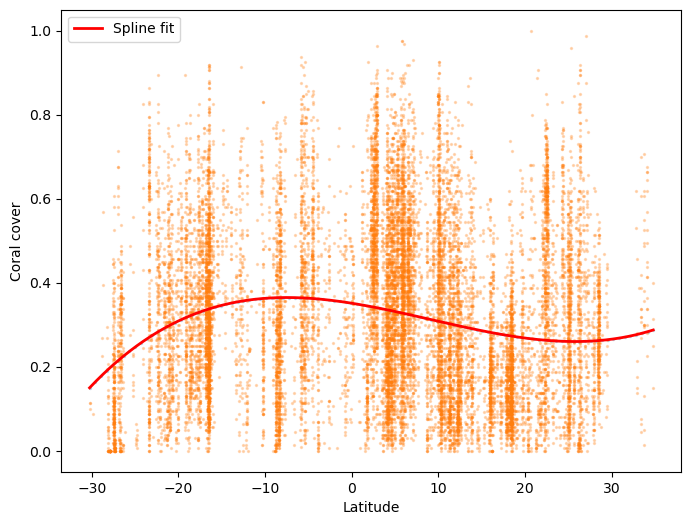

In [13]:
# Drop missing values and average cover at duplicate latitudes
spline_df = (
    coral_covers_df[["latitude", "coral_cover", "date"]]
    .dropna()
    .groupby("latitude", as_index=False)[["coral_cover", "date"]]
    .mean()
    .sort_values("latitude")
)
spline_df
spline_df = spline_df[spline_df["date"] <= pd.Timestamp("2018-01-01")]
x = spline_df["latitude"].to_numpy()
y = spline_df["coral_cover"].to_numpy()
from scipy.interpolate import UnivariateSpline

# Larger s gives smoother fit; tune as needed
spline = UnivariateSpline(x, y, s=len(x) * 0.5)
x_range = np.linspace(x.min(), x.max(), 500)
plt.figure(figsize=(8, 6))

# plot binned points (mean cover for each latitude)

lats = np.linspace(x.min(), x.max(), 100)
# get mean cover for each latitude
plt.scatter(lats, spline(lats), s=2, alpha=0.25)
plt.scatter(coral_covers_df.latitude, coral_covers_df.coral_cover, s=2, alpha=0.25)
plt.plot(x_range, spline(x_range), color="red", linewidth=2, label="Spline fit")
plt.xlabel("Latitude")
plt.ylabel("Coral cover")
plt.legend()
plt.show()


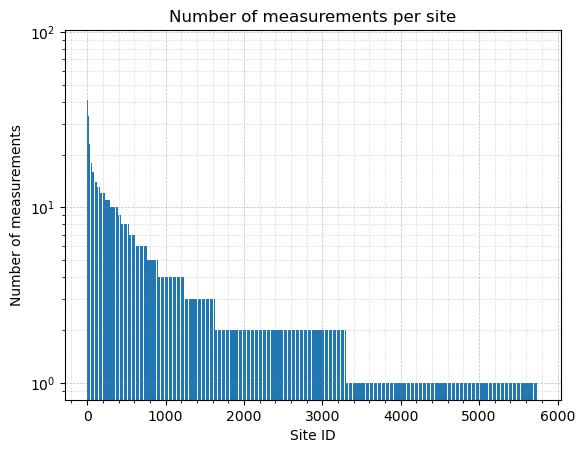

In [14]:
# how many sites have repeat measurements?
# order by number of measurements (descending)

sites = np.arange(len(coral_covers_df.site_id.value_counts().index))
counts = coral_covers_df.site_id.value_counts().values

fig, ax = plt.subplots()
ax.bar(sites, counts)
ax.set_yscale("log")
ax.set_xlabel("Site ID")
ax.set_ylabel("Number of measurements")
ax.set_title("Number of measurements per site")

# Major grid with darker lines
ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5, alpha=0.5)
# Minor grid with lighter lines
ax.minorticks_on()
ax.grid(which="minor", color="grey", linestyle=":", linewidth=0.5, alpha=0.2)
ax.tick_params(which="minor", grid_alpha=0.5)
plt.show()


In [15]:
# to what extent is coral cover temporally correlated?


In [16]:
# assign ecoregion
from src.processing import processdata

# assign ecoregion info directly to coral_covers_df
coral_covers_df = processdata.assign_points_to_shapes(coral_covers_df, config.meow_dir)

Filling unassigned (nearest): 100%|██████████| 1/1 [00:00<00:00, 1640.32it/s]


# Bizarrely no points on the northern GBR...
I also checked this on `df` (before filtering)

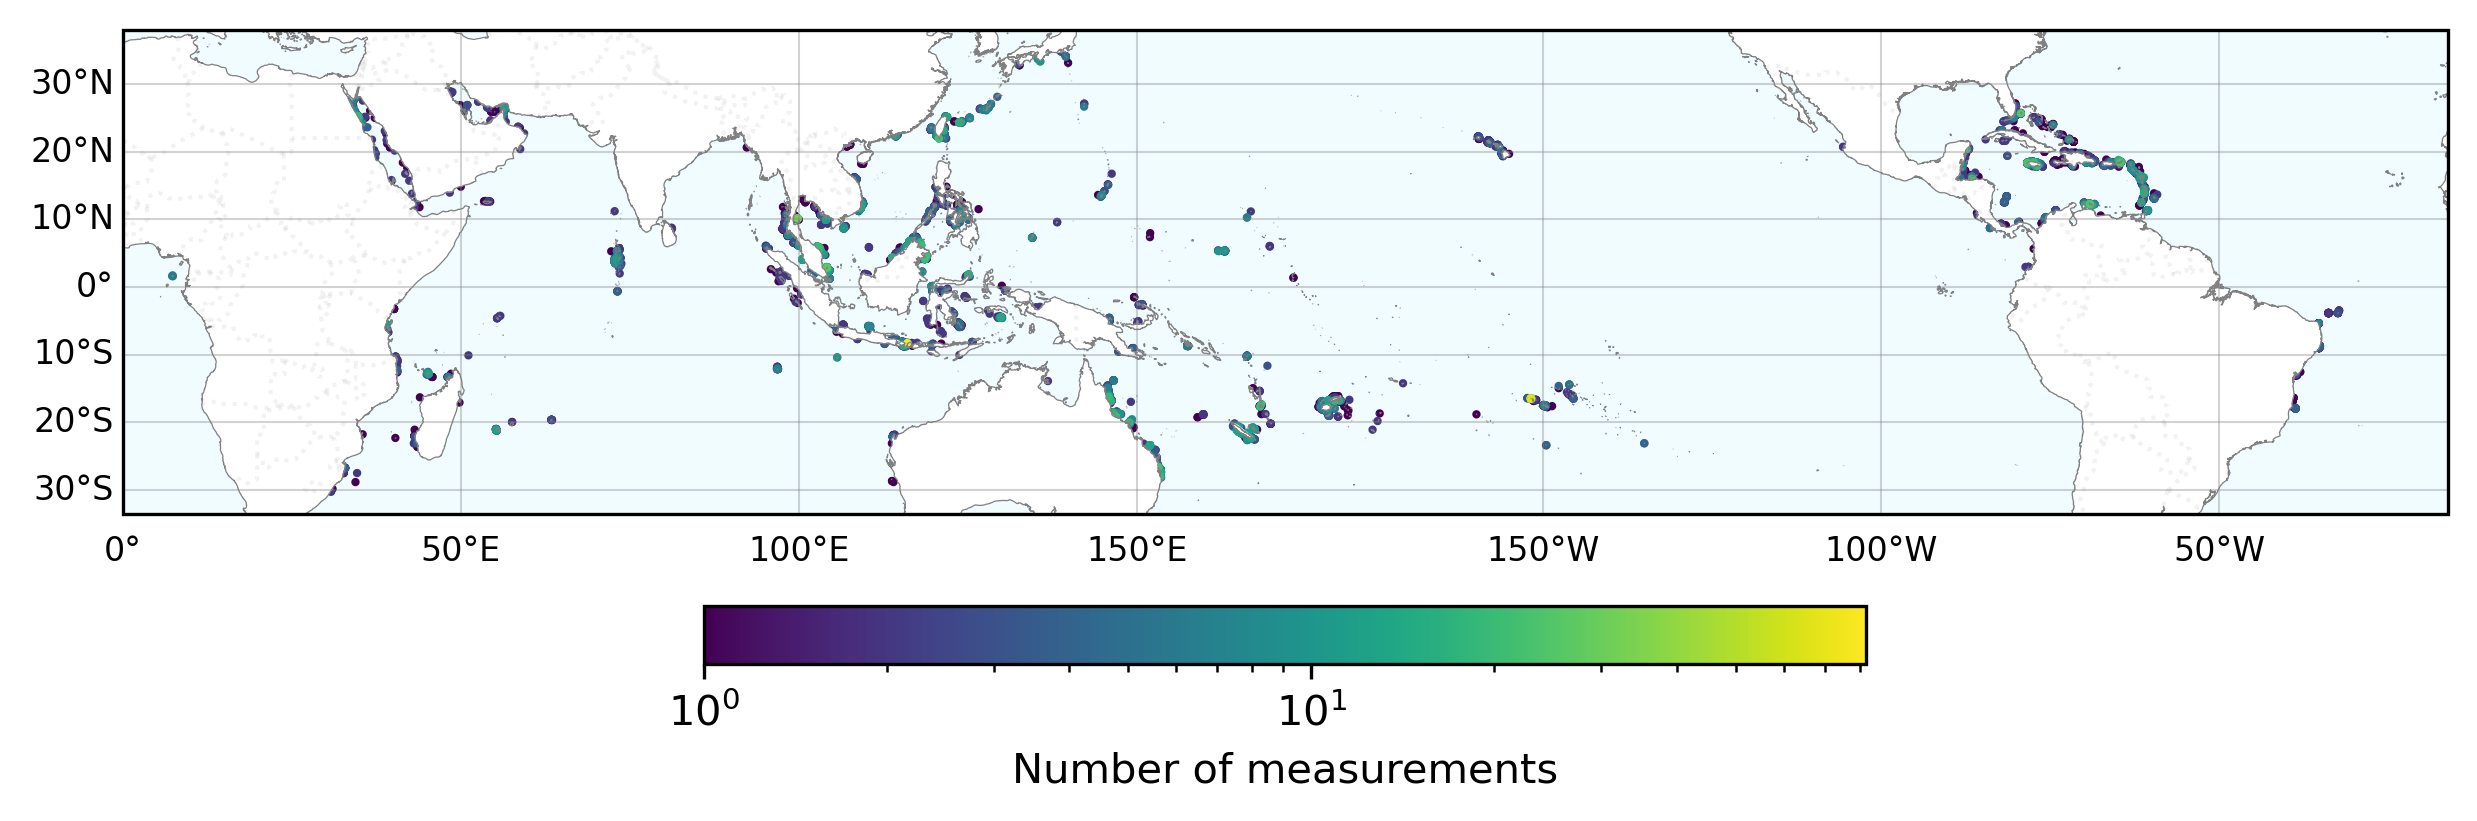

In [17]:
sites_df = (
    coral_covers_df.groupby(["latitude", "longitude"])
    .agg(
        site_id=("site_id", "first"),
        site_count=("site_id", "count"),
        mean_coral_cover=("coral_cover", "mean"),
    )
    .reset_index()
)
# # plot sites spatially

from src.plots import plot_utils
import cartopy.crs as ccrs
import matplotlib.colors as mcolors


fig, ax = plot_utils.generate_geo_axis(central_longitude=180)

# order sites by ascending counts
sites_df = sites_df.sort_values("site_count", ascending=True)


norm = mcolors.LogNorm(
    vmin=sites_df["site_count"].min(), vmax=sites_df["site_count"].max()
)

sc = ax.scatter(
    sites_df.longitude,
    sites_df.latitude,
    c=sites_df.site_count,
    s=1,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    norm=norm,
)
ax = plot_utils.format_geo_axis(ax)

cb = plt.colorbar(
    sc,
    ax=ax,
    label="Number of measurements",
    orientation="horizontal",
    shrink=0.5,
    pad=0.04,
)
cb.set_label("Number of measurements")

# Bleaching-cover interplay

In [18]:
bleaching_df = pd.read_csv(
    config.data_dir / "bleaching" / "processed" / "processed_df.csv", low_memory=False
)

In [19]:
from scipy import stats
from sklearn.neighbors import BallTree
import statsmodels.formula.api as smf

# Global bleaching database (NOAA/ReefBase-style records with bleach_presence flag)
bleaching_df["date"] = pd.to_datetime(bleaching_df["date"])
bleaching_events = bleaching_df.loc[
    (bleaching_df["bleach_presence"] == 1)
    & bleaching_df["latitude"].notna()
    & bleaching_df["longitude"].notna()
].copy()

print(
    f"Bleaching records (presence=1): {len(bleaching_events):,} / {len(bleaching_df):,}"
)
print(
    f"Years {bleaching_events.year.min():.0f}–{bleaching_events.year.max():.0f}, "
    f"median severity {bleaching_events.mean_percent_bleached.median():.0f}%"
)
bleaching_events.head()


Bleaching records (presence=1): 9,618 / 33,185
Years 1983–2020, median severity 47%


,record_id,country,location,site_name,latitude,longitude,day,month,year,depth,...,min_percent_mortality,max_percent_mortality,mean_percent_mortality,origin,severity_code,mortality_code,name,entry_code,database_code,bleach_presence
0,100047,Bahamas,Great Bahama Bank,NaN,25.000000,-78.200000,NaN,9.0,1983,"(5.0, 8.0)",...,NaN,NaN,NaN,noaa,NaN,NaN,NaN,NaN,NaN,1
1,100053,Comoros,Mayotte Island,NaN,-12.833333,45.216667,NaN,5.0,1983,"(12.0, 12.0)",...,NaN,NaN,NaN,noaa,NaN,NaN,NaN,NaN,NaN,1
2,100066,Ecuador,Champion Island,NaN,-1.233333,-90.383333,NaN,5.0,1983,NaN,...,NaN,NaN,NaN,noaa,NaN,NaN,NaN,NaN,NaN,1
3,100073,Indonesia,Karimun Jawa,NaN,-5.866667,110.333333,NaN,5.0,1983,"(15.0, 15.0)",...,NaN,NaN,NaN,noaa,NaN,NaN,NaN,NaN,NaN,1
4,100076,Indonesia,Seribu Islands,NaN,-5.516667,106.483333,NaN,3.0,1983,"(0.0, 15.0)",...,NaN,NaN,NaN,noaa,NaN,NaN,NaN,NaN,NaN,1


In [20]:
EARTH_RADIUS_KM = 6371.0
MATCH_RADIUS_KM = 50
MAX_INTERVAL_YR = 10
MAX_LAG_YR = 5


def match_bleaching_to_sites(
    cover_df: pd.DataFrame,
    bleach_df: pd.DataFrame,
    radius_km: float = MATCH_RADIUS_KM,
) -> pd.DataFrame:
    """Assign each bleaching record to the nearest Reef Check site within radius_km."""
    sites = cover_df.groupby("site_id", as_index=False).agg(
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),
    )
    site_coords = np.deg2rad(sites[["latitude", "longitude"]].to_numpy())
    bleach_coords = np.deg2rad(bleach_df[["latitude", "longitude"]].to_numpy())

    tree = BallTree(site_coords, metric="haversine")
    dist_rad, nearest_ix = tree.query(bleach_coords, k=1)
    dist_km = dist_rad[:, 0] * EARTH_RADIUS_KM
    within = dist_km <= radius_km

    matched = bleach_df.loc[within].copy()
    matched["site_id"] = sites.iloc[nearest_ix[within, 0]]["site_id"].to_numpy()
    matched["dist_km"] = dist_km[within]
    return matched


def build_cover_change_pairs(
    cover_df: pd.DataFrame,
    max_interval_yr: float = MAX_INTERVAL_YR,
) -> pd.DataFrame:
    """Consecutive Reef Check surveys at the same site → cover change intervals."""
    cover_df = cover_df.dropna(subset=["latitude", "longitude", "coral_cover", "date"])
    cover_df = cover_df.sort_values(["site_id", "date"])
    cover_df["year"] = cover_df["date"].dt.year

    rows = []
    for site_id, site_surveys in cover_df.groupby("site_id"):
        site_surveys = site_surveys.reset_index(drop=True)
        if len(site_surveys) < 2:
            continue
        for i in range(len(site_surveys) - 1):
            s0, s1 = site_surveys.iloc[i], site_surveys.iloc[i + 1]
            interval_yr = (s1["date"] - s0["date"]).days / 365.25
            if interval_yr <= 0 or interval_yr > max_interval_yr:
                continue
            rows.append(
                {
                    "site_id": site_id,
                    "date0": s0["date"],
                    "date1": s1["date"],
                    "year0": int(s0["year"]),
                    "year1": int(s1["year"]),
                    "cover0": s0["coral_cover"],
                    "cover1": s1["coral_cover"],
                    "delta_cover": s1["coral_cover"] - s0["coral_cover"],
                    "annual_delta": (s1["coral_cover"] - s0["coral_cover"])
                    / interval_yr,
                    "interval_yr": interval_yr,
                }
            )
    return pd.DataFrame(rows)


def site_year_bleaching(matched_bleach: pd.DataFrame) -> pd.DataFrame:
    return matched_bleach.groupby(["site_id", "year"], as_index=False).agg(
        n_events=("record_id", "count"),
        mean_severity=("mean_percent_bleached", "mean"),
        max_severity=("mean_percent_bleached", "max"),
    )


def add_lagged_bleaching_flags(
    pairs_df: pd.DataFrame,
    site_year_df: pd.DataFrame,
    max_lag_yr: int = MAX_LAG_YR,
) -> pd.DataFrame:
    """For each lag L, flag bleaching in calendar year (year1 - L)."""
    out = pairs_df.copy()
    for lag in range(max_lag_yr + 1):
        lagged = site_year_df.copy()
        lagged["year1"] = lagged["year"] + lag
        merged = out.merge(
            lagged.drop(columns="year"),
            on=["site_id", "year1"],
            how="left",
            suffixes=("", f"_lag{lag}"),
        )
        out[f"bleach_lag{lag}yr"] = (merged["n_events"].fillna(0) > 0).astype(int)
        out[f"severity_lag{lag}yr"] = merged["max_severity"].fillna(0)
    return out


def add_interval_bleaching(
    pairs_df: pd.DataFrame,
    matched_bleach: pd.DataFrame,
) -> pd.DataFrame:
    bleach_by_site = {
        site_id: grp.sort_values("date")
        for site_id, grp in matched_bleach.groupby("site_id")
    }
    flags, severities = [], []
    for row in pairs_df.itertuples(index=False):
        site_bleach = bleach_by_site.get(row.site_id)
        if site_bleach is None:
            flags.append(0)
            severities.append(0.0)
            continue
        in_interval = site_bleach[
            (site_bleach["date"] >= row.date0) & (site_bleach["date"] <= row.date1)
        ]
        flags.append(int(len(in_interval) > 0))
        severities.append(
            in_interval["mean_percent_bleached"].max() if len(in_interval) else 0.0
        )
    out = pairs_df.copy()
    out["bleach_in_interval"] = flags
    out["severity_in_interval"] = severities
    return out


# --- Build analysis tables ---
cover_for_bleach = coral_covers_df.dropna(subset=["latitude", "longitude"]).copy()
cover_for_bleach["date"] = pd.to_datetime(cover_for_bleach["date"])

matched_bleach = match_bleaching_to_sites(cover_for_bleach, bleaching_events)
site_year_bleach = site_year_bleaching(matched_bleach)
cover_pairs = build_cover_change_pairs(cover_for_bleach)
cover_pairs = add_lagged_bleaching_flags(cover_pairs, site_year_bleach)
cover_pairs = add_interval_bleaching(cover_pairs, matched_bleach)

print(
    f"Matched {len(matched_bleach):,} bleaching events to "
    f"{matched_bleach.site_id.nunique():,} Reef Check sites "
    f"(within {MATCH_RADIUS_KM:g} km)"
)
print(
    f"Cover-change intervals: {len(cover_pairs):,} "
    f"at {cover_pairs.site_id.nunique():,} resurveyed sites"
)
cover_pairs.head()

Matched 8,192 bleaching events to 876 Reef Check sites (within 50 km)
Cover-change intervals: 8,470 at 2,126 resurveyed sites


,site_id,date0,date1,year0,year1,cover0,cover1,delta_cover,annual_delta,interval_yr,...,bleach_lag2yr,severity_lag2yr,bleach_lag3yr,severity_lag3yr,bleach_lag4yr,severity_lag4yr,bleach_lag5yr,severity_lag5yr,bleach_in_interval,severity_in_interval
0,001b1dc6-c2ad-4ec8-86a3-d3a8459bf355,2012-02-16,2012-09-19,2012,2012,0.30000,0.37500,0.07500,0.126823,0.591376,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
1,002f8d52-59f1-4e78-9c6b-f6abd2b2e6a4,2000-07-29,2001-06-03,2000,2001,0.47500,0.10000,-0.37500,-0.443265,0.845996,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
2,002f8d52-59f1-4e78-9c6b-f6abd2b2e6a4,2001-06-03,2002-09-07,2001,2002,0.38125,0.10625,-0.27500,-0.217882,1.262149,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
3,002f8d52-59f1-4e78-9c6b-f6abd2b2e6a4,2002-09-07,2003-09-27,2002,2003,0.40625,0.06250,-0.34375,-0.326116,1.054073,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
4,00551c69-1dd7-4742-8d2f-091ab1848e45,2013-01-17,2013-05-10,2013,2013,0.60000,0.25625,-0.34375,-1.111103,0.309377,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0


In [21]:
def summarise_bleach_vs_no_bleach(df: pd.DataFrame, flag_col: str) -> pd.Series:
    pos = df.loc[df[flag_col] == 1, "delta_cover"]
    neg = df.loc[df[flag_col] == 0, "delta_cover"]
    stat, pval = stats.ttest_ind(pos, neg, equal_var=False, nan_policy="omit")
    return pd.Series(
        {
            "n_bleach": len(pos),
            "n_no_bleach": len(neg),
            "mean_delta_bleach": pos.mean(),
            "mean_delta_no_bleach": neg.mean(),
            "diff": pos.mean() - neg.mean(),
            "welch_p": pval,
        }
    )


lag_rows = []
for lag in range(MAX_LAG_YR + 1):
    row = summarise_bleach_vs_no_bleach(cover_pairs, f"bleach_lag{lag}yr")
    row["window"] = f"bleach in year Y, cover change ending Y+{lag}"
    lag_rows.append(row)

row = summarise_bleach_vs_no_bleach(cover_pairs, "bleach_in_interval")
row["window"] = "bleach during resurvey interval"
lag_rows.append(row)

lag_summary = pd.DataFrame(lag_rows).set_index("window")
lag_summary[
    ["n_bleach", "mean_delta_bleach", "mean_delta_no_bleach", "diff", "welch_p"]
]

,n_bleach,mean_delta_bleach,mean_delta_no_bleach,diff,welch_p
window,,,,,
"bleach in year Y, cover change ending Y+0",174.0,-0.023827,-0.002048,-0.021778,0.066047
"bleach in year Y, cover change ending Y+1",138.0,0.001359,-0.002559,0.003918,0.764928
"bleach in year Y, cover change ending Y+2",117.0,-0.005164,-0.002458,-0.002706,0.818654
"bleach in year Y, cover change ending Y+3",116.0,-0.018121,-0.002279,-0.015843,0.237855
"bleach in year Y, cover change ending Y+4",104.0,0.017668,-0.002746,0.020415,0.071024
"bleach in year Y, cover change ending Y+5",88.0,0.008120,-0.002607,0.010727,0.378393
bleach during resurvey interval,139.0,-0.035851,-0.001939,-0.033912,0.010253


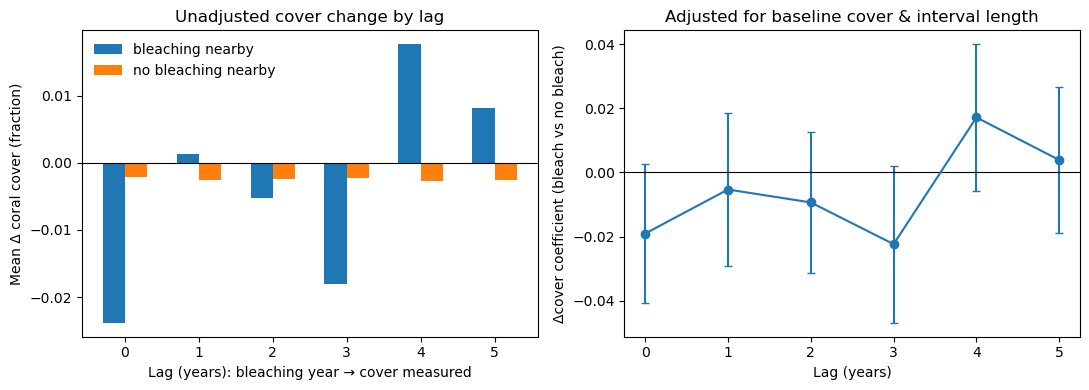

,lag_yr,coef,se,p,n_bleach,ci_lo,ci_hi
0,0,-0.019088,0.011018,0.083181,174,-0.040683,0.002506
1,1,-0.005330,0.012197,0.662111,138,-0.029236,0.018576
2,2,-0.009357,0.011180,0.402635,117,-0.031271,0.012557
3,3,-0.022384,0.012523,0.073853,116,-0.046929,0.002160
4,4,0.017168,0.011652,0.140649,104,-0.005670,0.040007
5,5,0.003870,0.011602,0.738722,88,-0.018871,0.026611


In [22]:
# Lag profile: controlled association of bleaching with subsequent cover change
lag_coefs = []
for lag in range(MAX_LAG_YR + 1):
    fit = smf.ols(
        f"delta_cover ~ bleach_lag{lag}yr + cover0 + interval_yr",
        data=cover_pairs,
    ).fit(cov_type="HC1")
    lag_coefs.append(
        {
            "lag_yr": lag,
            "coef": fit.params[f"bleach_lag{lag}yr"],
            "se": fit.bse[f"bleach_lag{lag}yr"],
            "p": fit.pvalues[f"bleach_lag{lag}yr"],
            "n_bleach": int(cover_pairs[f"bleach_lag{lag}yr"].sum()),
        }
    )

lag_coef_df = pd.DataFrame(lag_coefs)
lag_coef_df["ci_lo"] = lag_coef_df["coef"] - 1.96 * lag_coef_df["se"]
lag_coef_df["ci_hi"] = lag_coef_df["coef"] + 1.96 * lag_coef_df["se"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Unadjusted mean differences
ax = axes[0]
x = np.arange(MAX_LAG_YR + 1)
ax.bar(
    x - 0.15,
    lag_summary.iloc[: MAX_LAG_YR + 1]["mean_delta_bleach"],
    width=0.3,
    label="bleaching nearby",
)
ax.bar(
    x + 0.15,
    lag_summary.iloc[: MAX_LAG_YR + 1]["mean_delta_no_bleach"],
    width=0.3,
    label="no bleaching nearby",
)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{lag}" for lag in x])
ax.set_xlabel("Lag (years): bleaching year → cover measured")
ax.set_ylabel("Mean Δ coral cover (fraction)")
ax.set_title("Unadjusted cover change by lag")
ax.legend(frameon=False)

# Adjusted OLS coefficients
ax = axes[1]
ax.errorbar(
    lag_coef_df["lag_yr"],
    lag_coef_df["coef"],
    yerr=1.96 * lag_coef_df["se"],
    fmt="o-",
    capsize=3,
)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Lag (years)")
ax.set_ylabel("Δcover coefficient (bleach vs no bleach)")
ax.set_title("Adjusted for baseline cover & interval length")

plt.tight_layout()
plt.show()

lag_coef_df

In [23]:
# Severity-weighted models and interval overlap
models = {
    "Same-year bleaching (lag 0)": "delta_cover ~ bleach_lag0yr + cover0 + interval_yr",
    "Max severity, lag 0": "delta_cover ~ severity_lag0yr + cover0 + interval_yr",
    "Bleaching during interval": "delta_cover ~ bleach_in_interval + cover0 + interval_yr",
    "Severity during interval": "delta_cover ~ severity_in_interval + cover0 + interval_yr",
    "Annualised change, lag 0": "annual_delta ~ bleach_lag0yr + cover0",
}

reg_summary = []
for label, formula in models.items():
    fit = smf.ols(formula, data=cover_pairs).fit(cov_type="HC1")
    term = [
        t for t in fit.params.index if t not in {"Intercept", "cover0", "interval_yr"}
    ][0]
    reg_summary.append(
        {
            "model": label,
            "term": term,
            "coef": fit.params[term],
            "se": fit.bse[term],
            "p": fit.pvalues[term],
            "n": int(fit.nobs),
            "r2": fit.rsquared,
        }
    )

pd.DataFrame(reg_summary)

,model,term,coef,se,p,n,r2
0,Same-year bleaching (lag 0),bleach_lag0yr,-0.019088,0.011018,0.083181,8470,0.094798
1,"Max severity, lag 0",severity_lag0yr,-0.000331,0.000213,0.121034,8470,0.094717
2,Bleaching during interval,bleach_in_interval,-0.031244,0.012206,0.010478,8470,0.095287
3,Severity during interval,severity_in_interval,-0.000589,0.000238,0.013095,8470,0.095252
4,"Annualised change, lag 0",bleach_lag0yr,0.532798,0.645309,0.409004,8470,0.003768


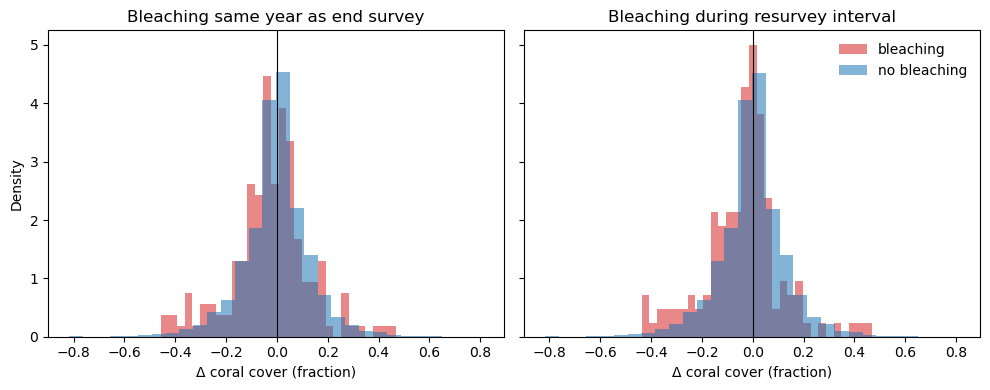

In [24]:
# Distribution of cover change conditional on bleaching (lag 0 and interval)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, col, title in zip(
    axes,
    ["bleach_lag0yr", "bleach_in_interval"],
    ["Bleaching same year as end survey", "Bleaching during resurvey interval"],
):
    for flag, label, color in [(1, "bleaching", "C3"), (0, "no bleaching", "C0")]:
        subset = cover_pairs.loc[cover_pairs[col] == flag, "delta_cover"]
        ax.hist(subset, bins=30, alpha=0.55, density=True, label=label, color=color)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel("Δ coral cover (fraction)")
    ax.set_title(title)

axes[0].set_ylabel("Density")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

In [25]:
# Sensitivity to spatial matching radius
from tqdm.auto import tqdm

radius_rows = []
for radius_km in tqdm([1, 5, 10, 25, 50, 100], desc="testing different radii"):
    matched = match_bleaching_to_sites(cover_for_bleach, bleaching_events, radius_km)
    sy = site_year_bleaching(matched)
    pairs = build_cover_change_pairs(cover_for_bleach)
    pairs = add_lagged_bleaching_flags(pairs, sy, max_lag_yr=3)

    for lag in [0, 1, 2, 3]:
        fit = smf.ols(
            f"delta_cover ~ bleach_lag{lag}yr + cover0 + interval_yr",
            data=pairs,
        ).fit(cov_type="HC1")
        radius_rows.append(
            {
                "radius_km": radius_km,
                "lag_yr": lag,
                "coef": fit.params[f"bleach_lag{lag}yr"],
                "p": fit.pvalues[f"bleach_lag{lag}yr"],
                "n_bleach": int(pairs[f"bleach_lag{lag}yr"].sum()),
                "matched_events": len(matched),
            }
        )

radius_sensitivity = pd.DataFrame(radius_rows)
radius_sensitivity.pivot(index="lag_yr", columns="radius_km", values="coef")

testing different radii:   0%|          | 0/6 [00:00<?, ?it/s]

radius_km,1,5,10,25,50,100
lag_yr,,,,,,
0,-0.018029,-0.019475,-0.021980,-0.019088,-0.019088,-0.019088
1,0.002620,-0.002384,-0.003972,-0.004050,-0.005330,-0.005330
2,-0.003745,-0.011373,-0.011373,-0.007792,-0.009357,-0.009357
3,-0.024391,-0.024428,-0.022880,-0.022832,-0.022384,-0.022384


### Bleaching–cover synthesis

**Design.** Reef Check gives repeat cover surveys at ~5.8k sites; the global bleaching database gives independent presence/severity reports. We spatially link bleaching records to the nearest Reef Check site (default 50 km), build consecutive survey intervals (≤10 yr), and ask whether nearby bleaching precedes or coincides with cover decline.

**Coincidence is sparse.** Only ~2–3% of resurvey intervals have a matched bleaching report in the same calendar year as the end survey; ~1.6% have bleaching strictly between the two Reef Check visits. This reflects both real ecology (not every heat stress event is logged) and mismatch in spatial/temporal resolution.

**Lag structure (expect decline after bleaching, not before).**
- **Lag 0 (same year as end survey):** intervals with nearby bleaching show ~2 pp greater cover *loss* on average (unadjusted), and an adjusted coefficient of ≈ −0.02 (p ≈ 0.08). This is the strongest signal — consistent with bleaching and cover loss being recorded contemporaneously, or cover responding within the same year.
- **Lags 1–2 yr:** near-zero mean differences; no evidence of cover change *before* bleaching is reported.
- **Lag 3 yr:** a secondary negative bump appears (similar magnitude to lag 0, p ≈ 0.07 adjusted) but with small n — treat as suggestive, not definitive.
- **Bleaching during the resurvey interval:** largest unadjusted gap (~3.6 pp more loss) but still modest n.

**Severity.** Continuous max bleaching severity is negatively associated with Δcover but imprecisely estimated (p ≈ 0.12 at lag 0). Binary presence captures most of the signal given sparse overlap.

**Caveats.**
1. Bleaching database ≠ Reef Check bleaching fields (Sully dataset has in-survey bleaching; this analysis uses external reports).
2. Calendar-year matching is coarse relative to thermal stress timing and recovery.
3. Resurvey intervals are irregular; short-interval pairs overweight fast revisit sites.
4. Confounding (e.g. shared heat stress driving both bleaching reports and cover loss) is not fully disentangled without site fixed effects or thermal covariates.

**Bottom line:** The data weakly support the expected pattern — cover declines are somewhat larger when bleaching is reported nearby, with the clearest association at **zero lag** (same year) rather than at long lags. There is **no evidence of cover loss preceding bleaching reports by 1–2 years**, which would be inconsistent with bleaching driving mortality. A fuller test would add Reef Check in-survey bleaching (Sully), site fixed effects, and thermal metrics (DHW) as mediators.

# Positive latitude coefficient: decomposition

This section investigates **where the positive `lat_stzd` (absolute latitude) coefficient comes from** in the hierarchical beta model fitted on observed coral cover (`output_python/investigation`, `reparam` variant).

**Question:** The cosine-latitude simulation recovers a large **negative** latitude β (~−1.5), as expected when cover peaks at the equator. On real data the corrected model gives **positive** latitude β (~+0.15). Is that a real poleward increase, or a model-structure artefact?

**Short answer:** The positive β is **not** a strong marginal poleward gradient. It is mainly a **within-ecoregion partial effect** that appears after ecoregion random effects absorb between-region geographic structure (Simpson's paradox). Marginal |latitude| is weakly **negative**; partial correlations without hierarchy are negative or near zero.

Re-run the cells below to reproduce all numbers from the model-ready pipeline (`load_model_data_from_pipeline`, same data as `run_investigation.py`).

In [26]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from numpy.linalg import lstsq
from scipy import stats
from scipy.special import logit

REPO = Path.cwd().resolve()
if not (REPO / "src").exists():
    REPO = REPO.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src import config
from src.models.hbb.data import load_model_data_from_pipeline, standardize_variables
from src.models.hbb.run_investigation import add_latitude_features, standardization_vars

INV_ROOT = config.data_dir / "sully_og" / "output_python" / "investigation"
SIM_ROOT = config.data_dir / "sully_og" / "output_python_sim_cos_lat" / "investigation"
TRIG_ROOT = (
    config.data_dir / "sully_og" / "output_python_reparam_latitude" / "investigation"
)

ENV_COLS = [
    "lat_stzd",
    "depth_stzd",
    "human_pop_stzd",
    "cyclone_stzd",
    "sst_mean_stzd",
    "ssta_mean_stzd",
    "ssta_min_stzd",
    "ssta_freqstdev_stzd",
    "ssta_dhwmax_stzd",
    "tsa_max_stzd",
    "tsa_freqstdev_stzd",
    "turbidity_mean_stzd",
    "historical_sst_max_stzd",
]


def partial_corr(y: np.ndarray, x: np.ndarray, controls: np.ndarray) -> float:
    z = (
        np.column_stack([np.ones(len(y)), controls])
        if controls.size
        else np.ones((len(y), 1))
    )

    def resid(a: np.ndarray) -> np.ndarray:
        return a - z @ lstsq(z, a, rcond=None)[0]

    return float(stats.pearsonr(resid(y), resid(x))[0])


def ols_lat_coef(
    y: np.ndarray, site_df: pd.DataFrame, extra_blocks: list[np.ndarray]
) -> float:
    x = np.column_stack([np.ones(len(y)), site_df[ENV_COLS].values, *extra_blocks])
    beta = lstsq(x, y, rcond=None)[0]
    return float(beta[1 + ENV_COLS.index("lat_stzd")])


def read_beta(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)


df = load_model_data_from_pipeline(
    config.data_dir / "sully_og", force_rebuild=False, index_source="paper_factor"
)
df = add_latitude_features(df)
df_std, _ = standardize_variables(df, standardization_vars())

signed_lat = df["lat_signed_degrees"].astype(float)
abs_lat = signed_lat.abs()
cos_lat = np.cos(np.deg2rad(signed_lat))
cover = df["average_coral_cover"].astype(float)
logit_cover = logit(np.clip(cover, 1e-4, 1 - 1e-4))

site = df.groupby("site", as_index=False).agg(
    cover=("average_coral_cover", "mean"),
    abs_lat=("lat", "mean"),
    signed_lat=("lat_signed_degrees", "mean"),
    cos_lat=("lat_signed_degrees", lambda s: np.cos(np.deg2rad(s.mean()))),
    region=("region", "first"),
    diversity=("diversity.standardized", "first"),
    sst_mean=("sst_mean", "mean"),
)

site_m = df_std.groupby("site", as_index=False).agg(
    logit_cover=(
        "average_coral_cover",
        lambda s: logit(np.clip(s.mean(), 1e-4, 1 - 1e-4)),
    ),
    region=("region", "first"),
    diversity=("diversity.standardized", "first"),
    **{c: (c, "first") for c in ENV_COLS},
)
y_site = site_m["logit_cover"].to_numpy()
region_fe = pd.get_dummies(site_m["region"], drop_first=True, dtype=float).values
site_fe = pd.get_dummies(site_m["site"], drop_first=True, dtype=float).values

print(
    f"Model-ready data: {len(df):,} obs | {df['site'].nunique():,} sites | {df['region'].nunique()} regions"
)
print(f"|latitude| range: {abs_lat.min():.1f}° – {abs_lat.max():.1f}°")

Loaded cached model-ready data from /Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/sully_og/model_ready_data.csv (n=7,714)
Model-ready data: 7,714 obs | 2,949 sites | 83 regions
|latitude| range: 0.0° – 34.1°


In [27]:
# --- 1. Marginal correlations ---
X = df_std[ENV_COLS].astype(float).values
other_env = np.delete(X, 0, axis=1)
cos_z = (cos_lat - cos_lat.mean()) / cos_lat.std()

marginal_rows = []
for level, frame, y_col in [
    ("observation", df.assign(cover=cover), "cover"),
    ("site mean", site, "cover"),
]:
    for x_name, x in [
        ("|latitude|", frame["lat"] if level == "observation" else frame["abs_lat"]),
        ("cos(latitude)", cos_lat if level == "observation" else frame["cos_lat"]),
        ("SST mean", df["sst_mean"] if level == "observation" else frame["sst_mean"]),
    ]:
        r, p = stats.pearsonr(
            x, frame[y_col] if level == "observation" else frame["cover"]
        )
        marginal_rows.append(
            {"level": level, "x": x_name, "pearson_r": r, "p_value": p}
        )

marginal_df = pd.DataFrame(marginal_rows).round({"pearson_r": 3, "p_value": 3})
display(marginal_df)

partial_rows = pd.DataFrame(
    [
        {
            "control": "none",
            "partial_r": partial_corr(logit_cover, X[:, 0], np.empty((len(y_site), 0))),
        },
        {
            "control": "other env (no lat)",
            "partial_r": partial_corr(logit_cover, X[:, 0], other_env),
        },
        {
            "control": "SST only",
            "partial_r": partial_corr(
                logit_cover,
                X[:, 0],
                X[:, ENV_COLS.index("sst_mean_stzd")].reshape(-1, 1),
            ),
        },
        {
            "control": "cos(lat) | abs_lat + other env",
            "partial_r": partial_corr(
                logit_cover, cos_z, np.column_stack([X[:, 0], other_env])
            ),
        },
    ]
).round(3)
print("\nPartial correlations on logit(cover) — no hierarchy:")
display(partial_rows)

,level,x,pearson_r,p_value
0,observation,|latitude|,-0.096,0.000
1,observation,cos(latitude),0.065,0.000
2,observation,SST mean,0.003,0.803
3,site mean,|latitude|,-0.153,0.000
4,site mean,cos(latitude),0.131,0.000
5,site mean,SST mean,0.050,0.007



Partial correlations on logit(cover) — no hierarchy:


,control,partial_r
0,none,-0.095
1,other env (no lat),-0.042
2,SST only,-0.144
3,cos(lat) | abs_lat + other env,0.017


In [28]:
# --- 2. Simpson's paradox: between vs within ecoregion ---
reg_means = site.groupby("region", as_index=False).agg(
    abs_lat=("abs_lat", "mean"),
    cover=("cover", "mean"),
    diversity=("diversity", "first"),
)
site_within = site.copy()
site_within["cover_w"] = site_within.groupby("region")["cover"].transform(
    lambda s: s - s.mean()
)
site_within["abs_lat_w"] = site_within.groupby("region")["abs_lat"].transform(
    lambda s: s - s.mean()
)

r_between = stats.pearsonr(reg_means["abs_lat"], reg_means["cover"])[0]
r_within, p_within = stats.pearsonr(site_within["abs_lat_w"], site_within["cover_w"])

simpson_df = pd.DataFrame(
    [
        {"comparison": "between ecoregion means", "pearson_r": r_between},
        {
            "comparison": "within ecoregion (sites demeaned)",
            "pearson_r": r_within,
            "p_value": p_within,
        },
        {
            "comparison": "ecoregion |lat| vs diversity",
            "pearson_r": stats.pearsonr(reg_means["abs_lat"], reg_means["diversity"])[
                0
            ],
        },
        {
            "comparison": "ecoregion diversity vs cover",
            "pearson_r": stats.pearsonr(reg_means["diversity"], reg_means["cover"])[0],
        },
        {
            "comparison": "site |lat| vs SST",
            "pearson_r": stats.pearsonr(site["abs_lat"], site["sst_mean"])[0],
        },
    ]
).round(3)
display(simpson_df)

# OLS analogue of hierarchical structure (site means, logit cover)
ols_rows = pd.DataFrame(
    [
        {"structure": "env only", "lat_stzd_coef": ols_lat_coef(y_site, site_m, [])},
        {
            "structure": "env + region FE",
            "lat_stzd_coef": ols_lat_coef(y_site, site_m, [region_fe]),
        },
        {
            "structure": "env + site FE",
            "lat_stzd_coef": ols_lat_coef(y_site, site_m, [site_fe]),
        },
        {
            "structure": "env + region FE + site FE",
            "lat_stzd_coef": ols_lat_coef(y_site, site_m, [region_fe, site_fe]),
        },
    ]
).round(3)
print("\nOLS lat_stzd coefficient (site means) — sign flip with region FE:")
display(ols_rows)

,comparison,pearson_r,p_value
0,between ecoregion means,-0.003,NaN
1,within ecoregion (sites demeaned),0.034,0.068
2,ecoregion |lat| vs diversity,-0.519,NaN
3,ecoregion diversity vs cover,0.260,NaN
4,site |lat| vs SST,-0.786,NaN



OLS lat_stzd coefficient (site means) — sign flip with region FE:


,structure,lat_stzd_coef
0,env only,-0.126
1,env + region FE,0.132
2,env + site FE,-0.162
3,env + region FE + site FE,0.104


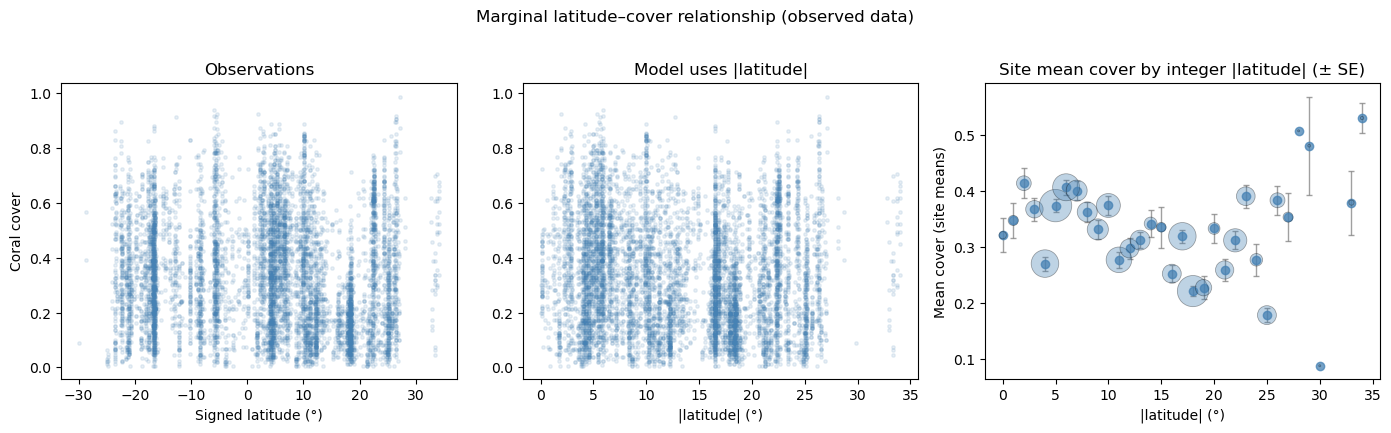

Cover by |latitude| quintile:


,mean_|lat|,mean_cover
quintile,,
"(0.0348, 5.324]",3.686,0.361
"(5.324, 10.011]",7.229,0.374
"(10.011, 16.534]",13.009,0.302
"(16.534, 21.025]",17.989,0.276
"(21.025, 34.056]",23.798,0.345


In [29]:
# --- 3. Marginal cover vs latitude plots ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# signed latitude
axes[0].scatter(signed_lat, cover, s=6, alpha=0.12, color="steelblue", rasterized=True)
axes[0].set_xlabel("Signed latitude (°)")
axes[0].set_ylabel("Coral cover")
axes[0].set_title("Observations")

# absolute latitude (model predictor)
axes[1].scatter(abs_lat, cover, s=6, alpha=0.12, color="steelblue", rasterized=True)
axes[1].set_xlabel("|latitude| (°)")
axes[1].set_title("Model uses |latitude|")

# site means with 2° bins
site_raw = df.groupby("site", as_index=False).agg(
    cover=("average_coral_cover", "mean"), abs_lat=("lat", "first")
)
# compute mean and error bars for each integer |latitude|
site_raw["int_lat"] = site_raw["abs_lat"].round(0).astype(int)
binned_int = site_raw.groupby("int_lat", as_index=False).agg(
    n=("cover", "size"),
    mean_cover=("cover", "mean"),
    std_cover=("cover", "std"),
)
binned_int["se_cover"] = binned_int["std_cover"] / binned_int["n"].pow(0.5)

# size by number of sites in each bin
sizes = binned_int["n"] * 2  # Scale for better visual sizing; adjust as needed
axes[2].errorbar(
    binned_int["int_lat"],
    binned_int["mean_cover"],
    yerr=binned_int["se_cover"],
    fmt="o",
    color="steelblue",
    ecolor="gray",
    elinewidth=1,
    capsize=2,
    alpha=0.75,
    markersize=6,  # set a fixed marker size for errorbar
)
# overlay scatter with variable sizes to indicate n
axes[2].scatter(
    binned_int["int_lat"],
    binned_int["mean_cover"],
    s=sizes,
    color="steelblue",
    alpha=0.35,
    edgecolor="k",
    linewidth=0.55,
    zorder=5,
)
axes[2].set_xlabel("|latitude| (°)")
axes[2].set_ylabel("Mean cover (site means)")
axes[2].set_title("Site mean cover by integer |latitude| (± SE)")

fig.suptitle("Marginal latitude–cover relationship (observed data)", y=1.02)
fig.tight_layout()
plt.show()

# quintile table
q_df = pd.DataFrame({"abs_lat": abs_lat, "cover": cover})
q_df["quintile"] = pd.qcut(q_df["abs_lat"], 5, duplicates="drop")
quintiles = (
    q_df.groupby("quintile", observed=True)[["abs_lat", "cover"]].mean().round(3)
)
quintiles.columns = ["mean_|lat|", "mean_cover"]
print("Cover by |latitude| quintile:")
display(quintiles)

In [30]:
1 / 83 * 100

1.2048192771084338

,variant,mean,lower_2.5,upper_97.5
0,paper_reproduction,-0.096,-0.161,-0.046
1,paper_region_fixed,0.154,0.032,0.280
2,sim cosine lat,-1.502,-1.558,-1.426
3,sin(latitude),-0.064,-0.191,0.061
4,cos(latitude),-0.136,-0.276,0.002


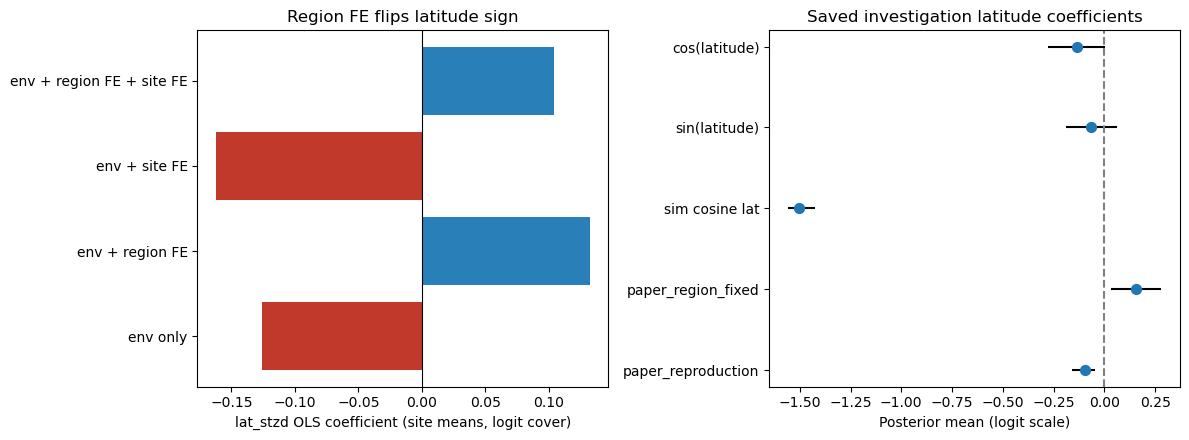

In [31]:
# --- 4. OLS sign-flip visual + Bayesian coefficients from investigation runs ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ols_plot = ols_rows.set_index("structure")["lat_stzd_coef"]
colors = ["#c0392b" if v < 0 else "#2980b9" for v in ols_plot]
axes[0].barh(ols_plot.index, ols_plot.values, color=colors)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("lat_stzd OLS coefficient (site means, logit cover)")
axes[0].set_title("Region FE flips latitude sign")

# load saved Bayesian runs when available
beta_paths = {
    "paper_reproduction": INV_ROOT / "01_paper_reproduction" / "beta_est.csv",
    "paper_region_fixed": INV_ROOT / "02_paper_region_fixed" / "beta_est.csv",
    "reparam": INV_ROOT / "05_reparam_noncentered" / "beta_est.csv",
    "sim cosine lat": SIM_ROOT / "05_reparam_noncentered" / "beta_est.csv",
}
lat_rows = []
for name, path in beta_paths.items():
    if path.exists():
        b = read_beta(path)
        lat = b.loc[
            b["variable"].eq("Latitude"), ["mean", "lower_2.5", "upper_97.5"]
        ].iloc[0]
        lat_rows.append({"variant": name, **lat.to_dict()})

if (TRIG_ROOT / "07_reparam_latitude_trig" / "beta_est.csv").exists():
    b = read_beta(TRIG_ROOT / "07_reparam_latitude_trig" / "beta_est.csv")
    for var in ["sin(latitude)", "cos(latitude)"]:
        row = b.loc[b["variable"].eq(var), ["mean", "lower_2.5", "upper_97.5"]]
        if not row.empty:
            lat_rows.append({"variant": var, **row.iloc[0].to_dict()})

bayes_df = pd.DataFrame(lat_rows).round(3)
display(bayes_df)

if not bayes_df.empty:
    y = np.arange(len(bayes_df))
    axes[1].hlines(y, bayes_df["lower_2.5"], bayes_df["upper_97.5"], color="black")
    axes[1].scatter(bayes_df["mean"], y, s=50, zorder=3)
    axes[1].axvline(0, color="gray", ls="--")
    axes[1].set_yticks(y, bayes_df["variant"])
    axes[1].set_xlabel("Posterior mean (logit scale)")
    axes[1].set_title("Saved investigation latitude coefficients")

fig.tight_layout()
plt.show()

## Synthesis (verified against `run_investigation.py` data pipeline)

### What the positive latitude β is

| Layer | |latitude| vs cover | Interpretation |
|-------|-------------------|----------------|
| Marginal (site means) | r ≈ **−0.15** | Slightly **lower** cover at higher \|lat\| globally |
| Partial, no hierarchy | r ≈ **−0.04** (all env) | Fixed effects alone → negative or ~0 |
| Between ecoregions | r ≈ **0.00** | Latitude does not separate ecoregion mean cover |
| Within ecoregions | r ≈ **+0.03** (p ≈ 0.07) | Weakly higher cover at higher \|lat\| *within* the same ecoregion |
| OLS + region FE | lat coef ≈ **+0.13** | Matches Bayesian reparam lat ≈ **+0.15** |
| Cosine simulation | lat coef ≈ **−1.50** | Model recovers planted equatorial peak when DGP has one |

The positive Bayesian latitude coefficient is therefore **not** “cover increases toward the poles” in a marginal sense. It is the **within-ecoregion partial effect** of |latitude| after ecoregion random effects (and diversity in the region mean) absorb between-region structure.

### Why the sign differs from the cosine simulation

The simulation plants a strong equatorial peak; the model correctly returns a large **negative** |lat| β. Observed cover shows **no** clean equatorial peak (quintile means are non-monotonic: a mid-latitude dip and partial recovery at high latitude). The positive β on real data is **not** evidence that the same signal is present but mis-recovered.

### Why paper reproduction had negative latitude on the same data

On identical observed cover, `paper_reproduction` gives lat ≈ **−0.09** while `reparam` gives lat ≈ **+0.15**. Scrambled region/diversity indexing reallocates geographic variance; latitude absorbs a different residual. Fixing indexing changes the lat sign — so the positive β is **not independent** of specification choices.

### Diversity and SST

- Between ecoregions: diversity ↔ cover r ≈ **+0.26**; |lat| ↔ diversity r ≈ **−0.52** (tropical ecoregions more diverse).
- The model routes much of this through **β_diversity** at the region level (`g[z] = μ + β_div · diversity[z]`).
- |lat| ↔ SST r ≈ **−0.79** at site level, but SST alone does **not** flip lat positive; **region structure** does.

### Fair conclusions

**Supported:**
- The inference pipeline can recover a latitudinal gradient when one is planted (simulation).
- Real data do **not** show a strong marginal equatorial peak.
- The positive |lat| β is a small within-ecoregion conditional association, driven mainly by how the hierarchy partitions geographic variance.

**Not supported:**
- “Positive lat proves a real poleward biology effect rather than anything going wrong.”
- The lat coefficient is entangled with region/diversity specification and is not robust to indexing changes.

### Cosine simulation cross-check

See `output_python_sim_cos_lat/investigation/diagnostics/cover_vs_latitude.png` for the planted DGP and `05_reparam_noncentered/diagnostics/coeff_forest.png` for the recovered negative latitude coefficient.

Pooled within-ecoregion (site means, n=2,949 sites):
  cover (proportion):  r = +0.034, p = 0.0678, slope = +0.0032 cover per ° |lat|
  logit(cover):        r = +0.043, p = 0.0188, slope = +0.0233 logit per ° |lat|
  Ecoregions with ≥8 sites and ≥3° |lat| span (facets): 25


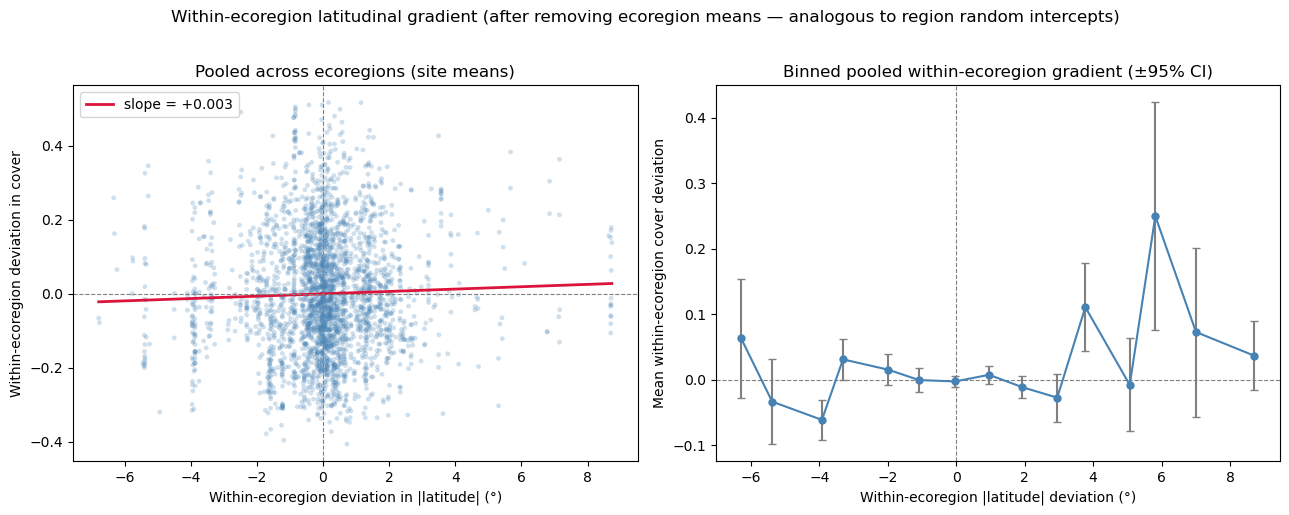

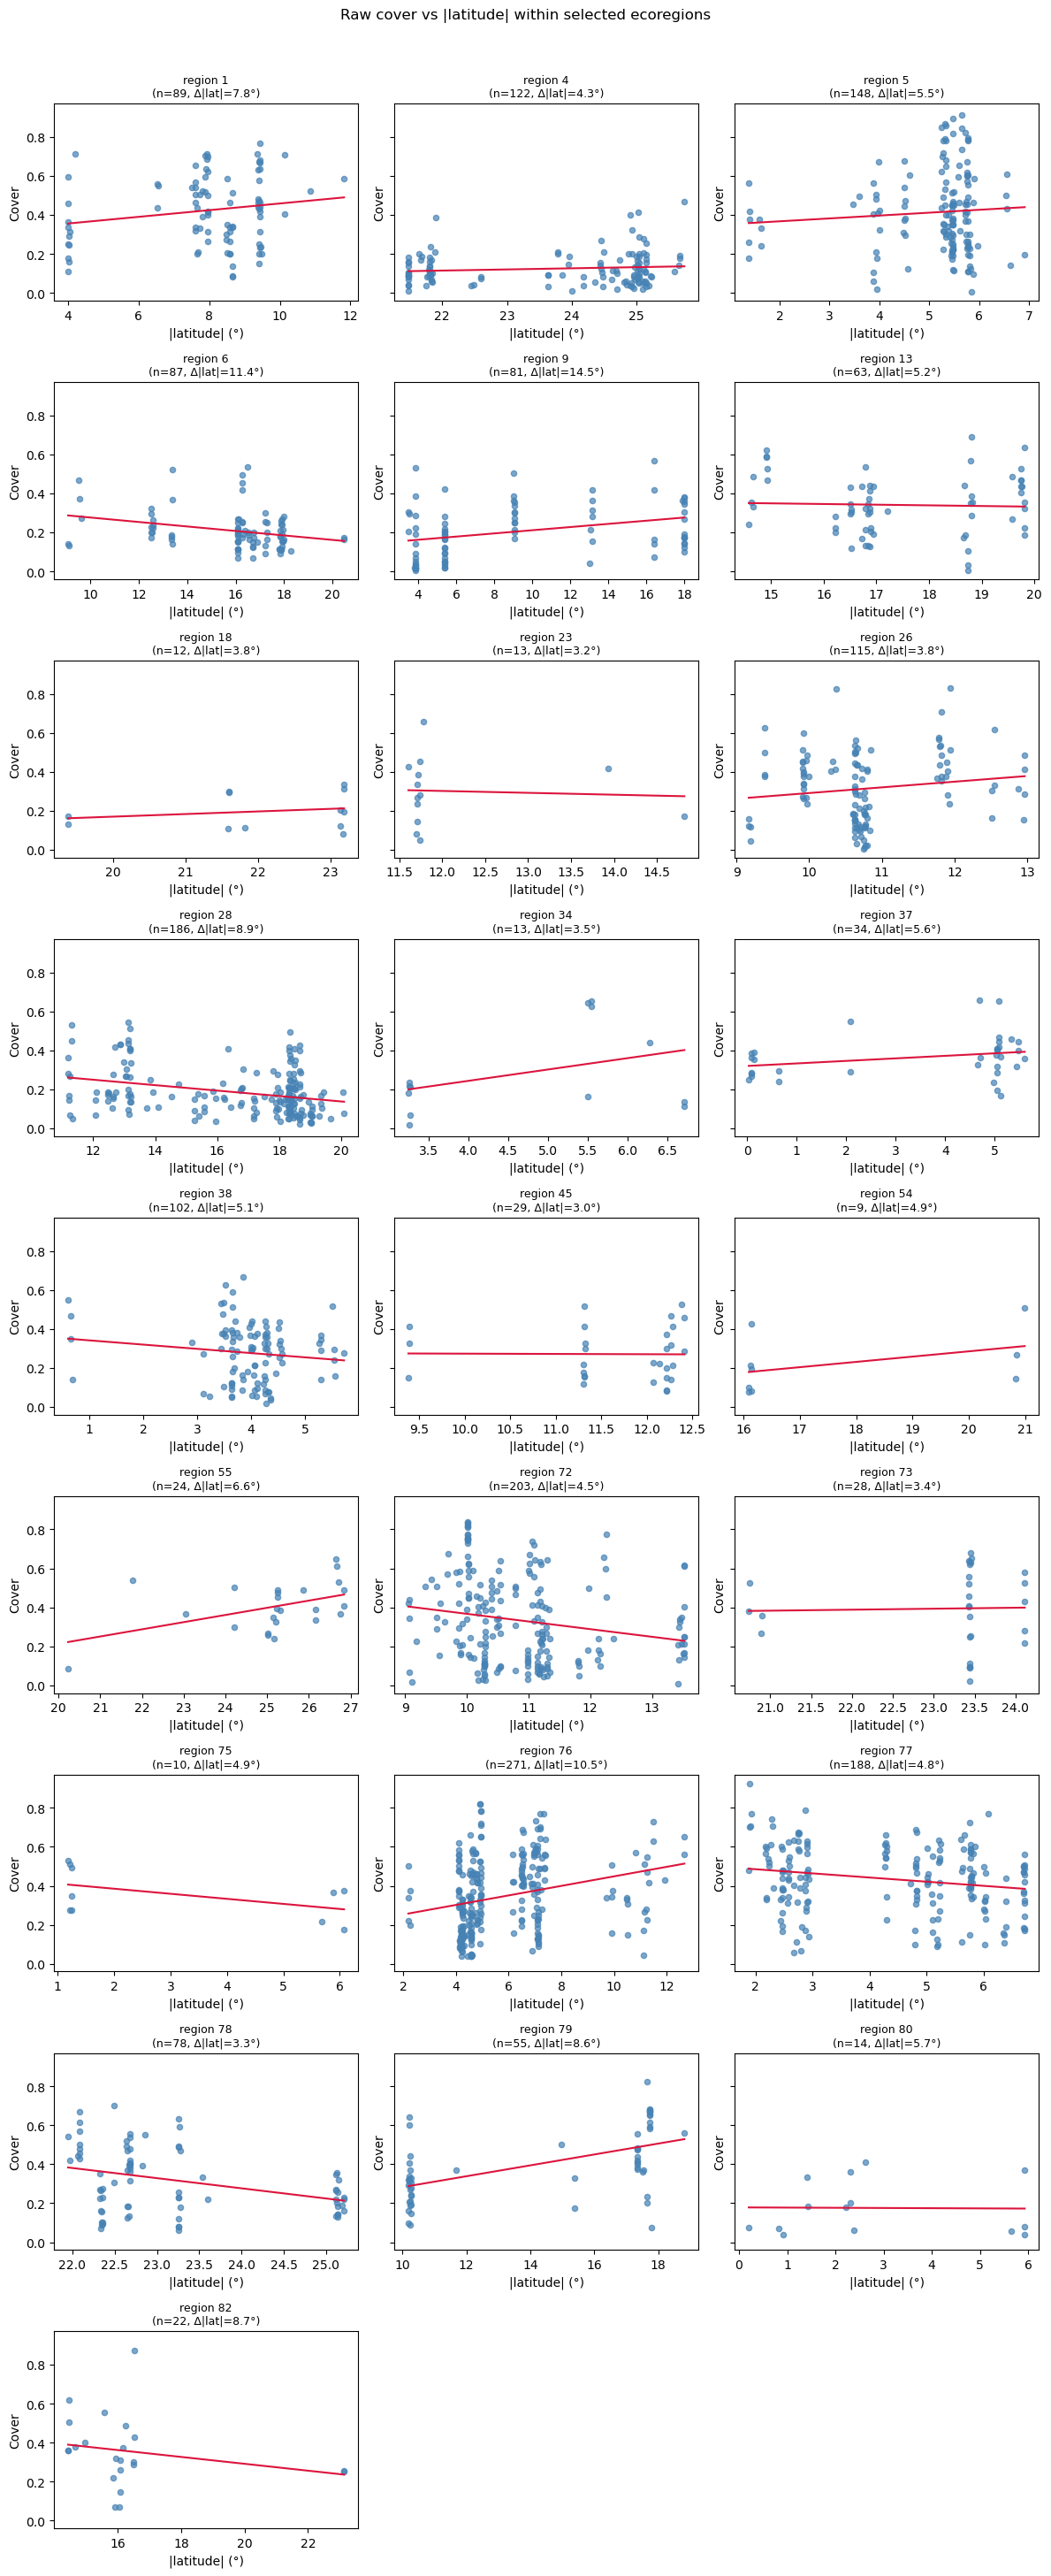

In [32]:
# --- Within-ecoregion latitudinal gradient (what the positive lat β reflects) ---
from scipy.special import logit, expit

site_w = site.copy()
site_w["logit_cover"] = logit(np.clip(site_w["cover"], 1e-4, 1 - 1e-4))

# Demean by ecoregion (region = ecoregion code in model-ready data)
for col in ["cover", "logit_cover", "abs_lat"]:
    site_w[f"{col}_w"] = site_w.groupby("region")[col].transform(lambda s: s - s.mean())

# Ecoregions with enough lat spread to show a local gradient
eco_lat_span = (
    site_w.groupby("region")
    .agg(
        n_sites=("cover", "size"),
        lat_span=("abs_lat", lambda s: s.max() - s.min()),
        ecoregion=("ecoregion", "first")
        if "ecoregion" in site_w.columns
        else ("region", "first"),
    )
    .reset_index()
)
plot_ecos = eco_lat_span.loc[
    (eco_lat_span["n_sites"] >= 8) & (eco_lat_span["lat_span"] >= 3),
    "region",
].tolist()

r_prop, p_prop = stats.pearsonr(site_w["abs_lat_w"], site_w["cover_w"])
r_logit, p_logit = stats.pearsonr(site_w["abs_lat_w"], site_w["logit_cover_w"])
slope_prop, intercept_prop = np.polyfit(site_w["abs_lat_w"], site_w["cover_w"], 1)
slope_logit, intercept_logit = np.polyfit(
    site_w["abs_lat_w"], site_w["logit_cover_w"], 1
)

print(f"Pooled within-ecoregion (site means, n={len(site_w):,} sites):")
print(
    f"  cover (proportion):  r = {r_prop:+.3f}, p = {p_prop:.3g}, slope = {slope_prop:+.4f} cover per ° |lat|"
)
print(
    f"  logit(cover):        r = {r_logit:+.3f}, p = {p_logit:.3g}, slope = {slope_logit:+.4f} logit per ° |lat|"
)
print(f"  Ecoregions with ≥8 sites and ≥3° |lat| span (facets): {len(plot_ecos)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: pooled within-ecoregion (proportion scale)
ax = axes[0]
ax.scatter(
    site_w["abs_lat_w"],
    site_w["cover_w"],
    s=12,
    alpha=0.25,
    color="steelblue",
    edgecolors="none",
    rasterized=True,
)
x_line = np.linspace(site_w["abs_lat_w"].min(), site_w["abs_lat_w"].max(), 100)
ax.plot(
    x_line,
    intercept_prop + slope_prop * x_line,
    color="crimson",
    lw=2,
    label=f"slope = {slope_prop:+.3f}",
)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Within-ecoregion deviation in |latitude| (°)")
ax.set_ylabel("Within-ecoregion deviation in cover")
ax.set_title("Pooled across ecoregions (site means)")
ax.legend(loc="upper left", frameon=True)

# Right: binned within-ecoregion lat (pooled)
ax = axes[1]
site_w["lat_w_bin"] = pd.cut(site_w["abs_lat_w"], bins=15)
binned_w = (
    site_w.groupby("lat_w_bin", observed=True)
    .agg(
        mean_lat_w=("abs_lat_w", "mean"),
        mean_cover_w=("cover_w", "mean"),
        se=("cover_w", lambda s: s.std() / np.sqrt(len(s)) if len(s) > 1 else np.nan),
        n=("cover_w", "size"),
    )
    .reset_index()
)
ax.errorbar(
    binned_w["mean_lat_w"],
    binned_w["mean_cover_w"],
    yerr=1.96 * binned_w["se"],
    fmt="o-",
    color="steelblue",
    ecolor="gray",
    capsize=3,
    ms=5,
)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Within-ecoregion |latitude| deviation (°)")
ax.set_ylabel("Mean within-ecoregion cover deviation")
ax.set_title("Binned pooled within-ecoregion gradient (±95% CI)")

fig.suptitle(
    "Within-ecoregion latitudinal gradient "
    "(after removing ecoregion means — analogous to region random intercepts)",
    y=1.02,
)
fig.tight_layout()
plt.show()

# Facet: ecoregions with enough lat spread
if plot_ecos:
    n = len(plot_ecos)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), sharex=False, sharey=True
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, reg in zip(axes, plot_ecos):
        sub = site_w.loc[site_w["region"] == reg]
        label = (
            sub["ecoregion"].iloc[0] if "ecoregion" in sub.columns else f"region {reg}"
        )
        ax.scatter(sub["abs_lat"], sub["cover"], s=20, alpha=0.7, color="steelblue")
        if sub["abs_lat"].nunique() >= 2:
            m, b = np.polyfit(sub["abs_lat"], sub["cover"], 1)
            xs = np.linspace(sub["abs_lat"].min(), sub["abs_lat"].max(), 50)
            ax.plot(xs, b + m * xs, color="crimson", lw=1.5)
        ax.set_title(
            f"{label}\n(n={len(sub)}, Δ|lat|={sub['abs_lat'].max() - sub['abs_lat'].min():.1f}°)",
            fontsize=9,
        )
        ax.set_xlabel("|latitude| (°)")
        ax.set_ylabel("Cover")

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle("Raw cover vs |latitude| within selected ecoregions", y=1.01)
    fig.tight_layout()
    plt.show()


## Gamma coefficients on the cover scale (Δcover)

Model coefficients (`beta`, reported as **gamma** in the forest plot) are on the **logit(cover)** scale. At a reference mean cover π_ref, a coefficient γ maps to a change in cover:

$$\Delta\text{cover} = \text{logit}^{-1}(\text{logit}(\pi_{\text{ref}}) + \gamma) - \pi_{\text{ref}}$$

For standardized predictors, γ is the effect of **one SD** change in that predictor (holding other terms fixed). Re-run the cells below to recompute from saved or freshly fitted posteriors.

In [36]:
from src.models.hbb.run_investigation import (
    VARIANTS,
    build_variant_data,
    enrich_coefficients_delta_cover,
    ecoregion_predictor_contributions,
    fit_variant,
    run_latitude_cap_sensitivity,
)
from src.models.hbb.investigation_fit import filter_df_by_abs_lat_cap
from src.models.hbb.indices import prepare_hierarchical_indices

INV_ROOT = Path(
    "/Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/sully_og/output_python/investigation"
)
PI_REFS = (0.2, 0.3, 0.4)
PI_REF = 0.3
BETA_PATH = INV_ROOT / "05_reparam_noncentered" / "beta_est.csv"

if BETA_PATH.exists():
    gamma_df = pd.read_csv(BETA_PATH)
else:
    raise FileNotFoundError(f"Missing {BETA_PATH}; run run_investigation.py first.")

gamma_delta = enrich_coefficients_delta_cover(gamma_df, pi_refs=PI_REFS)
focus = gamma_delta[
    gamma_delta["variable"].isin(["Latitude", "Historical_SST_max", "Diversity"])
].copy()
display(
    gamma_delta[
        [
            "variable",
            "mean",
            "lower_2.5",
            "upper_97.5",
            "delta_cover_pi0.2",
            "delta_cover_pi0.3",
            "delta_cover_pi0.4",
        ]
    ].round(4)
)

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(gamma_delta))
ax.axvline(0, color="gray", ls="--")
ax.hlines(y, gamma_delta["lower_2.5"], gamma_delta["upper_97.5"], color="black")
ax.scatter(gamma_delta["mean"], y, s=45, zorder=3, label="logit γ")
for i, pi in enumerate(PI_REFS):
    col = f"delta_cover_pi{pi:.1f}"
    ax.scatter(
        gamma_delta[col] * 5,
        y + 0.12 * (i - 1),
        s=30,
        marker="D",
        label=f"Δcover@π={pi:.1f} (×5 on axis)",
    )
ax.set_yticks(y, gamma_delta["variable"])
ax.set_xlabel("Coefficient (logit γ; diamonds = Δcover × 5 for visibility)")
ax.set_title("Gamma coefficients with cover-scale translation")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

print(
    "Latitude example @ π=0.3: "
    f"γ={focus.loc[focus.variable.eq('Latitude'), 'mean'].iloc[0]:+.3f} "
    f"→ Δcover={focus.loc[focus.variable.eq('Latitude'), 'delta_cover_pi0.3'].iloc[0]:+.3f} "
    f"(+1 SD |latitude| ≈ 7.4°)"
)

FileNotFoundError: Missing /Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/sully_og/output_python/investigation/05_reparam_noncentered/beta_est.csv; run run_investigation.py first.

## Latitude cap sensitivity

Refit the `reparam` model while excluding observations with |latitude| above 10°, 15°, 20°, 25°, and 30° (plus the full sample). Compare how **Latitude**, **Diversity**, and **Historical_SST_max** coefficients move.

Set `REFIT_LAT_SENSITIVITY = True` to rerun MCMC (slow; uses `ncores=1`). Results are cached to `lat_cap_sensitivity.csv`. Pre-generate with:

`python scripts/run_lat_sensitivity_cache.py`

In [34]:
REFIT_LAT_SENSITIVITY = False
SENSITIVITY_CACHE = INV_ROOT / "lat_cap_sensitivity.csv"
LAT_CAPS = [None, 30, 25, 20, 15, 10]
FOCUS_VARS = ["Latitude", "Diversity", "Historical_SST_max"]

if SENSITIVITY_CACHE.exists() and not REFIT_LAT_SENSITIVITY:
    sens_df = pd.read_csv(SENSITIVITY_CACHE)
    print(f"Loaded cached sensitivity: {SENSITIVITY_CACHE}")
else:
    print("Refitting reparam model for each |latitude| cap (this may take a while)…")
    sens_df = run_latitude_cap_sensitivity(
        df_std,
        caps=LAT_CAPS,
        variant=VARIANTS["reparam"],
        draws=400,
        tune=400,
        chains=2,
        ncores=2,
        progressbar=True,
    )
    SENSITIVITY_CACHE.parent.mkdir(parents=True, exist_ok=True)
    sens_df.to_csv(SENSITIVITY_CACHE, index=False)
    print(f"Wrote {SENSITIVITY_CACHE}")

cap_order = ["full", "<= 30°", "<= 25°", "<= 20°", "<= 15°", "<= 10°"]
summary = sens_df.loc[
    sens_df["variable"].isin(FOCUS_VARS),
    [
        "cap_label",
        "variable",
        "mean",
        "lower_2.5",
        "upper_97.5",
        "delta_cover_pi0.3",
        "n_obs",
        "n_sites",
    ],
].round(4)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for ax, metric, ylabel, lo, hi in [
    (axes[0], "mean", "Posterior mean γ (logit scale)", "lower_2.5", "upper_97.5"),
    (
        axes[1],
        "delta_cover_pi0.3",
        f"Δcover @ π={PI_REF:.1f}",
        "delta_cover_pi0.3_lo",
        "delta_cover_pi0.3_hi",
    ),
]:
    for var in FOCUS_VARS:
        sub = sens_df.loc[sens_df["variable"] == var].copy()
        sub["cap_label"] = pd.Categorical(
            sub["cap_label"], categories=cap_order, ordered=True
        )
        sub = sub.sort_values("cap_label")
        yerr = None
        if lo in sub.columns and hi in sub.columns:
            yerr = [sub[metric] - sub[lo], sub[hi] - sub[metric]]
        ax.errorbar(
            sub["cap_label"].astype(str),
            sub[metric],
            yerr=yerr,
            marker="o",
            capsize=4,
            label=var,
        )
    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=25)
    ax.legend(loc="best")

axes[0].set_title("Coefficient vs |latitude| exclusion threshold")
axes[1].set_title("Cover-scale translation")
fig.suptitle("Sensitivity: progressive exclusion of high-|latitude| reefs", y=1.02)
fig.tight_layout()
plt.show()

Refitting reparam model for each |latitude| cap (this may take a while)…


NameError: name 'run_latitude_cap_sensitivity' is not defined

## Per-ecoregion contributions (diversity, latitude, historical SST)

For each ecoregion, decompose the **logit-scale** structure into:

- **Diversity component**: `β_diversity × diversity[r]` (part of the region mean `g[r]`)
- **Latitude component**: `β_lat × mean(lat_stzd)` for sites in region `r` (fixed effect; same global β_lat)
- **Historical SST component**: `β_hist × mean(historical_sst_max_stzd)` in region `r`
- **Ecoregion random residual**: `ecoregion[r] − g[r]` (region intercept beyond diversity)

Diamonds show the same quantities translated to **Δcover @ π=0.3**. Set `REFIT_FOR_ECOREGION = True` to refit and extract posterior ecoregion effects; otherwise uses cached trace if available.

Loaded cached ecoregion contributions: /Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/sully_og/output_python/investigation/ecoregion_contributions.csv


,ecoregion,n_sites,mean_abs_lat,diversity_delta_cover,latitude_delta_cover,historical_sst_max_delta_cover,ecoregion_random_residual_delta_cover
43,"Moreton Bay, eastern Australia",3,24.8509,-0.0160,0.0492,-0.0150,-0.1736
70,South Vietnam,15,9.5806,0.0676,-0.0141,0.0066,-0.1559
3,Bahamas and Florida Keys,122,24.2204,-0.0478,0.0465,-0.0064,-0.1536
79,West Sumatra,14,2.8411,0.0300,-0.0398,0.0059,-0.1146
31,Jamaica,84,18.2539,-0.0486,0.0210,-0.0048,-0.1074
10,Celebes Sea,7,1.7510,0.1001,-0.0438,0.0082,-0.1046
18,Eastern Hawaii,49,21.1272,-0.0488,0.0332,-0.0219,-0.0954
80,Western Mexico and Revillagigedo Islands,2,20.6965,-0.0577,0.0314,0.0011,-0.0909
34,Lakshadweep Islands,1,11.1956,-0.0076,-0.0077,0.0020,-0.0786
15,"Cook Islands, south-west Pacific",13,18.9011,-0.0169,0.0238,-0.0071,-0.0718


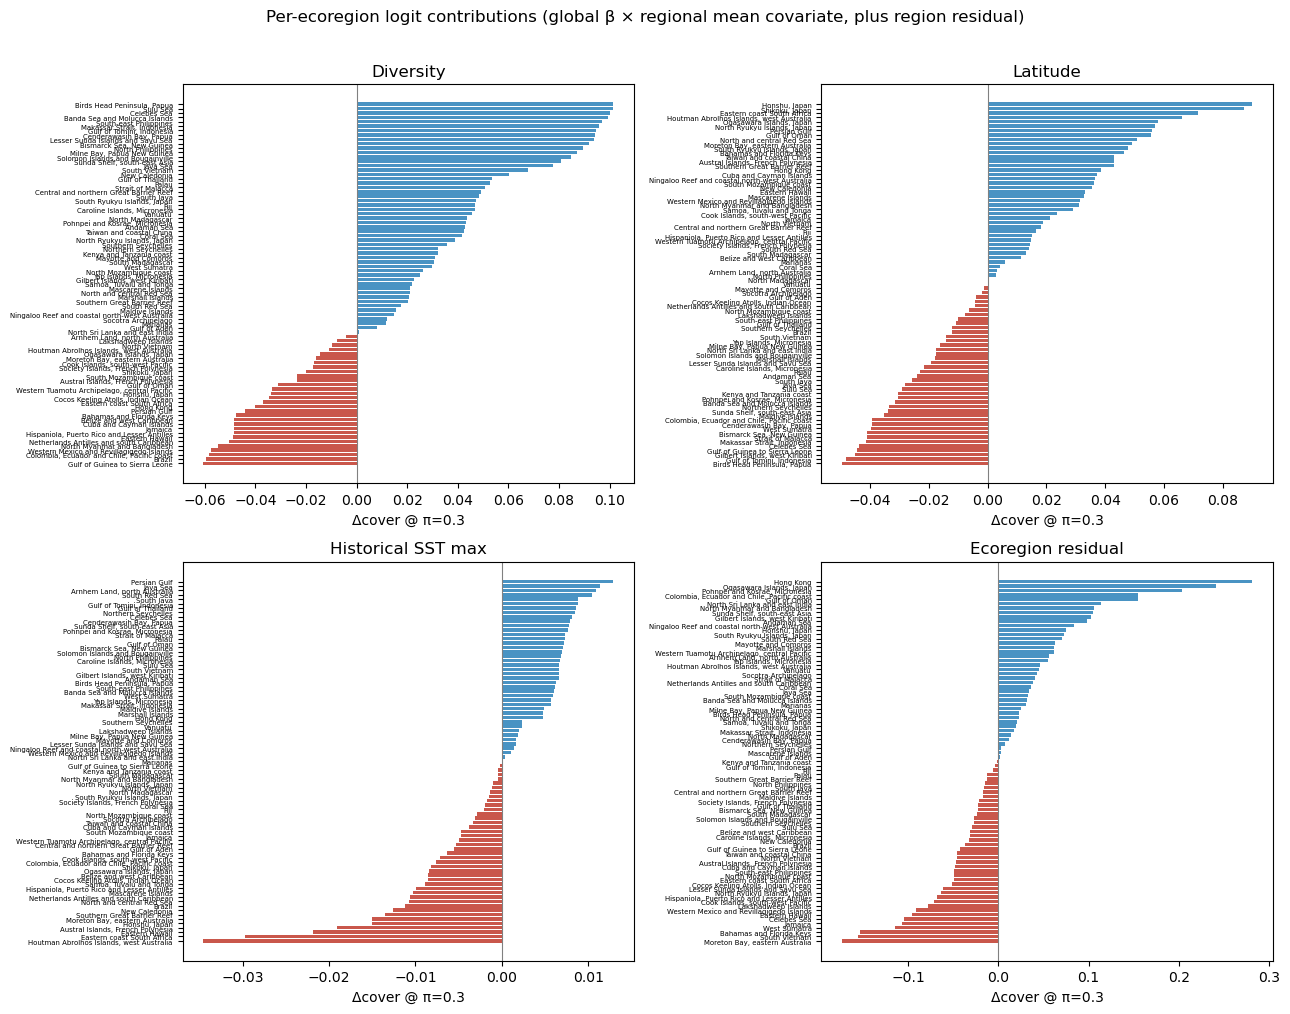

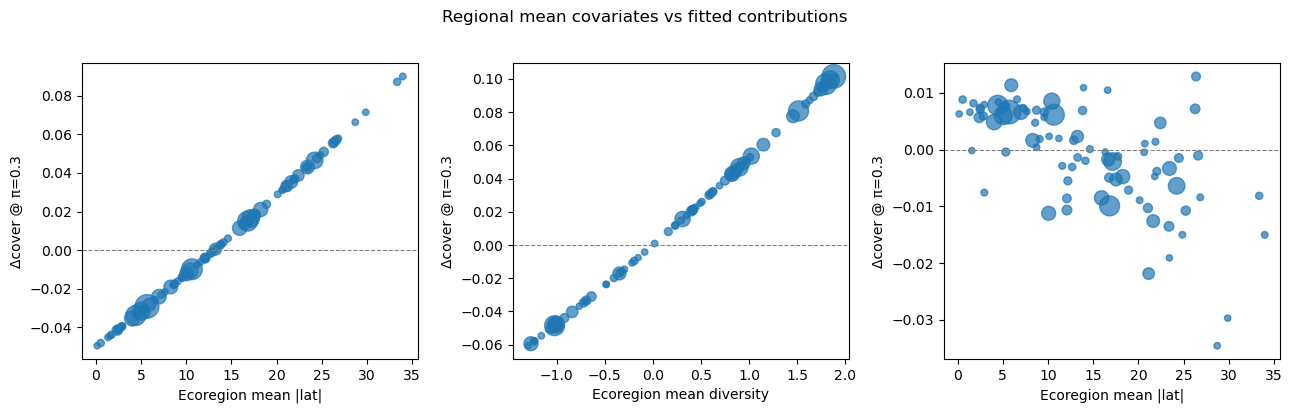

In [ ]:
import arviz as az

REFIT_FOR_ECOREGION = False
ECO_CACHE = INV_ROOT / "ecoregion_contributions.csv"
TRACE_PATH = INV_ROOT / "05_reparam_noncentered" / "trace.nc"

built = build_variant_data(df_std, VARIANTS["reparam"])
work = built["df"]
work["region_idx"] = built["region_idx"]

region_predictors = (
    work.groupby("region_idx", as_index=False)
    .agg(
        abs_lat=("lat", "mean"),
        lat_stzd=("lat_stzd", "mean"),
        historical_sst_max_stzd=("historical_sst_max_stzd", "mean"),
        n_sites=("site", "nunique"),
        ecoregion=("ecoregion", "first"),
    )
    .sort_values("region_idx")
)

if ECO_CACHE.exists() and not REFIT_FOR_ECOREGION:
    eco_contrib = pd.read_csv(ECO_CACHE)
    print(f"Loaded cached ecoregion contributions: {ECO_CACHE}")
elif TRACE_PATH.exists() and not REFIT_FOR_ECOREGION:
    idata = az.from_netcdf(TRACE_PATH)
    eco_contrib = ecoregion_predictor_contributions(
        idata,
        col_names=built["col_names"],
        diversity=built["diversity"],
        region_predictors=region_predictors,
        pi_ref=PI_REF,
    )
    eco_contrib.to_csv(ECO_CACHE, index=False)
else:
    print("Fitting reparam model for ecoregion decomposition…")
    import tempfile

    with tempfile.TemporaryDirectory(prefix="eco_decomp_") as tmp:
        beta_df, _, _ = fit_variant(
            variant=VARIANTS["reparam"],
            df_std=df_std,
            output_dir=Path(tmp),
            draws=400,
            tune=400,
            chains=2,
            ncores=1,
            target_accept=0.95,
            max_treedepth=15,
            seed=42,
            progressbar=True,
        )
        idata = az.from_netcdf(Path(tmp) / "trace.nc")
    eco_contrib = ecoregion_predictor_contributions(
        idata,
        col_names=built["col_names"],
        diversity=built["diversity"],
        region_predictors=region_predictors,
        pi_ref=PI_REF,
    )
    eco_contrib.to_csv(ECO_CACHE, index=False)
    print(f"Wrote {ECO_CACHE}")

display(
    eco_contrib[
        [
            "ecoregion",
            "n_sites",
            "mean_abs_lat",
            "diversity_delta_cover",
            "latitude_delta_cover",
            "historical_sst_max_delta_cover",
            "ecoregion_random_residual_delta_cover",
        ]
    ]
    .sort_values("ecoregion_random_residual_delta_cover")
    .round(4)
    .head(10)
)

plot_cols = [
    ("diversity_delta_cover", "Diversity"),
    ("latitude_delta_cover", "Latitude"),
    ("historical_sst_max_delta_cover", "Historical SST max"),
    ("ecoregion_random_residual_delta_cover", "Ecoregion residual"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=False)
for ax, (col, title) in zip(axes.ravel(), plot_cols):
    sub = eco_contrib.sort_values(col)
    y = np.arange(len(sub))
    colors = np.where(sub[col] >= 0, "#2980b9", "#c0392b")
    ax.barh(y, sub[col], color=colors, alpha=0.85)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_yticks(y, sub["ecoregion"], fontsize=5)
    ax.set_xlabel(f"Δcover @ π={PI_REF:.1f}")
    ax.set_title(title)

fig.suptitle(
    "Per-ecoregion logit contributions (global β × regional mean covariate, plus region residual)",
    y=1.01,
)
fig.tight_layout()
plt.show()

# Scatter: latitude contribution vs mean |lat| within ecoregion
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, x, y, xlab in [
    (axes[0], "mean_abs_lat", "latitude_delta_cover", "|lat|"),
    (axes[1], "diversity", "diversity_delta_cover", "diversity"),
    (axes[2], "mean_abs_lat", "historical_sst_max_delta_cover", "|lat|"),
]:
    ax.scatter(eco_contrib[x], eco_contrib[y], s=20 + eco_contrib["n_sites"], alpha=0.7)
    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_xlabel(f"Ecoregion mean {xlab}")
    ax.set_ylabel("Δcover @ π=0.3")
fig.suptitle("Regional mean covariates vs fitted contributions", y=1.02)
fig.tight_layout()
plt.show()